In [188]:
# %% 데이터 로드
import glob, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# seaborn 스타일을 먼저 적용 (이게 폰트를 덮어쓸 수 있어서 순서 중요!)
sns.set_style('whitegrid')

# 그 다음 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 출력 옵션
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)
 
from pathlib import Path
 
current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent
 
# ── 추정매출 로드 (기존 코드 재사용) ──
DATA_DIR = str(project_root / 'data' / 'extracted' / '서울시_상권분석서비스(추정매출+영역)') + '/'
pattern = DATA_DIR + '*추정매출*.csv'
sales_files = sorted(glob.glob(pattern))
print(f'추정매출 파일: {len(sales_files)}개')
 
sales = pd.concat(
    [pd.read_csv(f, encoding='cp949', low_memory=False) for f in sales_files],
    ignore_index=True
)
print(f'  → 통합: {sales.shape[0]:,}행 × {sales.shape[1]}컬럼')
 
# ── 영역 로드 ──
area_path = glob.glob(DATA_DIR + '*영역*상권*.csv')[0]
area = pd.read_csv(area_path, encoding='cp949')
print(f'영역: {area.shape[0]:,}개 상권')
 
# ── 길단위인구(유동인구) 로드 ──
floating_path = project_root / 'data' / 'extracted' / '서울시 상권분석서비스(길단위인구-상권)' / '서울시 상권분석서비스(길단위인구-상권).csv'
floating = pd.read_csv(floating_path, encoding='cp949')
print(f'유동인구: {floating.shape[0]:,}행 × {floating.shape[1]}컬럼')
 
# ── 직장인구 로드 ──
work_path = project_root / 'data' / '06_직장인구' / '서울시 상권분석서비스(직장인구-상권).csv'
df_직장 = pd.read_csv(work_path, encoding='cp949')
print(f'직장인구: {df_직장.shape[0]:,}행 × {df_직장.shape[1]}컬럼')
 
# ── 상주인구 로드 ──
resident_path = project_root / 'data' / '07_상주인구' / '서울시 상권분석서비스(상주인구-상권).csv'
df_상주 = pd.read_csv(resident_path, encoding='cp949')
print(f'상주인구: {df_상주.shape[0]:,}행 × {df_상주.shape[1]}컬럼')
 
print('\n✅ 전체 데이터 로드 완료')

추정매출 파일: 6개
  → 통합: 519,931행 × 55컬럼
영역: 1,650개 상권
유동인구: 46,184행 × 27컬럼
직장인구: 45,840행 × 26컬럼
상주인구: 40,812행 × 29컬럼

✅ 전체 데이터 로드 완료


**피드백**: 토요일뿐 아니라 평일·다른 요일도 보고, 자치구(동) 단위로 업종 쏠림 확인

In [189]:
# %% 관광특구 상권별 요일 편향 분석
요일_매출 = ['월요일_매출_금액','화요일_매출_금액','수요일_매출_금액','목요일_매출_금액',
            '금요일_매출_금액','토요일_매출_금액','일요일_매출_금액']
요일라벨 = ['월','화','수','목','금','토','일']
 
sales['상권_코드_명'] = sales['상권_코드_명'].str.replace('?', '·', regex=False)
 
관광 = sales[sales['상권_구분_코드_명'] == '관광특구'].merge(
    area[['상권_코드', '자치구_코드_명', '행정동_코드_명']], on='상권_코드', how='left'
)

시간_매출 = ['시간대_00~06_매출_금액', '시간대_06~11_매출_금액', '시간대_11~14_매출_금액',
           '시간대_14~17_매출_금액', '시간대_17~21_매출_금액', '시간대_21~24_매출_금액']
시간라벨 = ['00-06', '06-11', '11-14', '14-17', '17-21', '21-24']

In [190]:
# 상권별 업종 요일 편향 계산
결과 = []
for 상권 in sorted(관광['상권_코드_명'].unique()):
    sub = 관광[관광['상권_코드_명'] == 상권]
    자치구 = sub['자치구_코드_명'].mode().iloc[0] if len(sub) > 0 else ''
 
    업종 = sub.groupby('서비스_업종_코드_명')[요일_매출].sum()
    업종['총'] = 업종.sum(axis=1)
    업종 = 업종[업종['총'] > 업종['총'].quantile(0.3)]
 
    for i, d in enumerate(요일라벨):
        업종[f'비중_{d}'] = 업종[요일_매출[i]] / 업종['총'] * 100
 
    # 토요일 휴무 업종 + 의료·교육 업종 제외
    제외_업종 = ['일반의원','치과의원','의약품','스포츠클럽','스포츠 강습',
           '일반교습학원','골프연습장','의료기기','한의원']
    업종 = 업종[~업종.index.isin(제외_업종)]
    업종 = 업종[업종['비중_토'] >= 5]
 
    업종['평일비중'] = 업종[['비중_월', '비중_화', '비중_수', '비중_목']].mean(axis=1)
    업종['토편향'] = 업종['비중_토'] - 업종['평일비중']
    업종['금편향'] = 업종['비중_금'] - 업종['평일비중']
    업종['일편향'] = 업종['비중_일'] - 업종['평일비중']
 
    for name, row in 업종.iterrows():
        결과.append({
            '상권': 상권, '자치구': 자치구, '업종': name,
            '토편향': row['토편향'], '금편향': row['금편향'], '일편향': row['일편향'],
            '총매출': row['총']
        })
 
df_편향 = pd.DataFrame(결과)

In [191]:
# 출력
print('📊 관광특구 상권별 요일 편향 업종 (휴무 업종 제외)')
print('=' * 70)
for 상권 in sorted(df_편향['상권'].unique()):
    sub = df_편향[df_편향['상권'] == 상권]
    자치구 = sub['자치구'].iloc[0]
    print(f'\n▸ {상권} ({자치구})')
    print(f'  토요일 강세: ', end='')
    for _, row in sub.nlargest(3, '토편향').iterrows():
        print(f'{row["업종"]}({row["토편향"]:+.1f}%p)', end='  ')
    평일강세 = sub[sub['토편향'] < 0].nsmallest(3, '토편향')
    if len(평일강세) > 0:
        print(f'\n  평일 강세:   ', end='')
        for _, row in 평일강세.iterrows():
            평일값 = -row['토편향']
            print(f'{row["업종"]}(+{평일값:.1f}%p)', end='  ')
    else:
        print(f'\n  평일 강세:   해당 없음 (전 업종 토요일 우위)', end='')
    print()

📊 관광특구 상권별 요일 편향 업종 (휴무 업종 제외)

▸ 강남 마이스 관광특구 (강남구)
  토요일 강세: 완구(+16.1%p)  가구(+13.6%p)  가전제품(+8.6%p)  
  평일 강세:   화장품(+8.5%p)  시계및귀금속(+7.9%p)  일식음식점(+3.7%p)  

▸ 동대문패션타운 관광특구 (중구)
  토요일 강세: 섬유제품(+28.1%p)  운동/경기용품(+13.6%p)  가방(+9.4%p)  
  평일 강세:   가구(+11.0%p)  슈퍼마켓(+7.2%p)  일반의류(+3.7%p)  

▸ 명동 남대문 북창동 다동 무교동 관광특구 (중구)
  토요일 강세: 미용실(+11.7%p)  안경(+9.2%p)  신발(+5.3%p)  
  평일 강세:   미곡판매(+14.8%p)  문구(+13.2%p)  화초(+10.8%p)  

▸ 이태원 관광특구 (용산구)
  토요일 강세: 호프-간이주점(+22.4%p)  양식음식점(+18.7%p)  치킨전문점(+17.7%p)  
  평일 강세:   가방(+1.1%p)  

▸ 잠실 관광특구 (송파구)
  토요일 강세: 완구(+16.5%p)  가전제품(+13.9%p)  미용실(+13.3%p)  
  평일 강세:   섬유제품(+11.0%p)  

▸ 종로·청계 관광특구 (종로구)
  토요일 강세: 노래방(+10.7%p)  당구장(+10.4%p)  운동/경기용품(+8.4%p)  
  평일 강세:   컴퓨터및주변장치판매(+11.4%p)  일식음식점(+8.5%p)  외국어학원(+7.7%p)  


In [192]:
# %% 상권별 요일 핵심 업종 요약표
상권요약 = df_편향.groupby('상권').apply(
    lambda x: pd.Series({
        '자치구': x['자치구'].iloc[0],
        '토요일 강세 1위': x.nlargest(1, '토편향')['업종'].iloc[0],
        '토편향값': x['토편향'].max(),
        '금요일 강세 1위': x.nlargest(1, '금편향')['업종'].iloc[0],
        '금편향값': x['금편향'].max(),
        '평일 강세 1위': x[x['토편향'] < 0].nsmallest(1, '토편향')['업종'].iloc[0] if len(x[x['토편향'] < 0]) > 0 else '해당 없음',
        '평일편향값': -x['토편향'].min() if x['토편향'].min() < 0 else 0,
    })
).reset_index()

In [193]:
print('\n\n📊 관광특구 상권별 요일 핵심 업종 요약')
print(f'{"상권":<25} {"자치구":<6} {"토요일1위":<12} {"편향":>6} {"금요일1위":<12} {"편향":>6} {"평일1위":<12} {"편향":>6}')
print('-' * 95)
for _, row in 상권요약.iterrows():
    print(f'{row["상권"]:<25} {row["자치구"]:<6} {row["토요일 강세 1위"]:<12} {row["토편향값"]:>+5.1f}'
          f' {row["금요일 강세 1위"]:<12} {row["금편향값"]:>+5.1f}'
          f' {row["평일 강세 1위"]:<12} {row["평일편향값"]:>+5.1f}')



📊 관광특구 상권별 요일 핵심 업종 요약
상권                        자치구    토요일1위            편향 금요일1위            편향 평일1위             편향
-----------------------------------------------------------------------------------------------
강남 마이스 관광특구               강남구    완구           +16.1 완구            +8.3 화장품           +8.5
동대문패션타운 관광특구              중구     섬유제품         +28.1 호프-간이주점       +4.2 가구           +11.0
명동 남대문 북창동 다동 무교동 관광특구    중구     미용실          +11.7 육류판매         +14.2 미곡판매         +14.8
이태원 관광특구                  용산구    호프-간이주점      +22.4 치킨전문점         +8.3 가방            +1.1
잠실 관광특구                   송파구    완구           +16.5 피부관리실         +6.2 섬유제품         +11.0
종로·청계 관광특구                종로구    노래방          +10.7 노래방           +7.0 컴퓨터및주변장치판매   +11.4


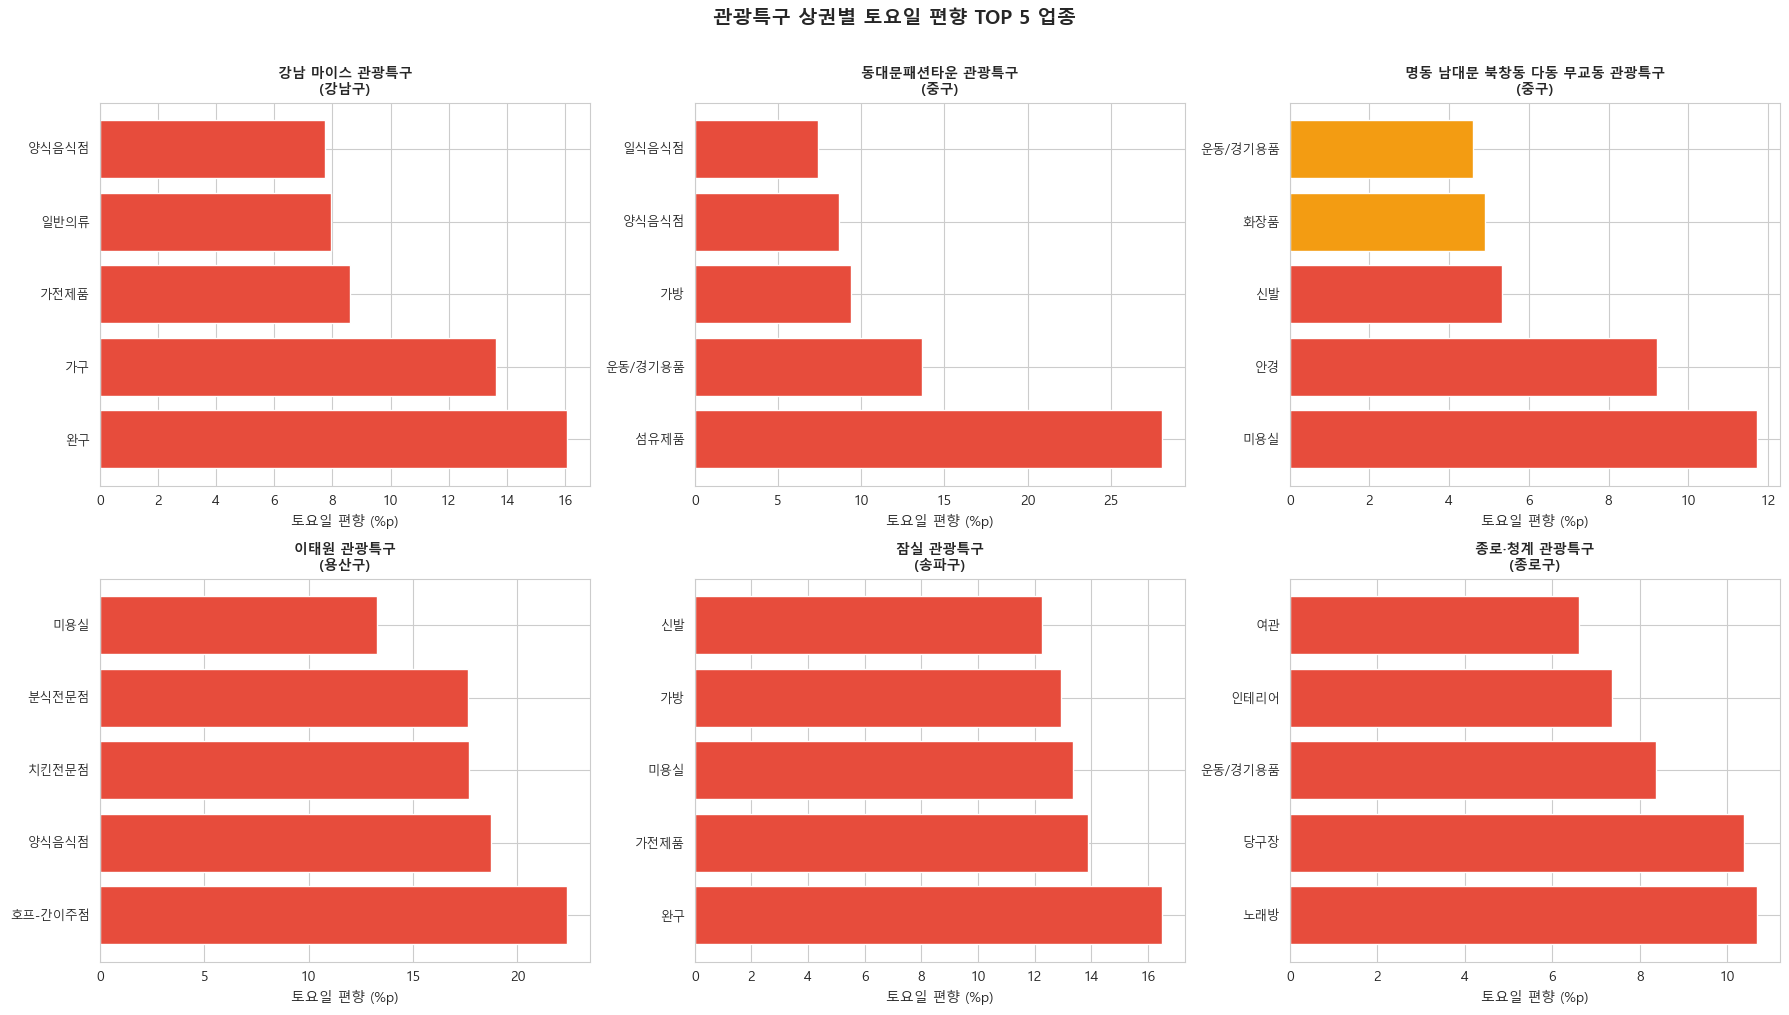

In [194]:
# %% 상권별 토요일 편향 TOP5 시각화
상권목록 = sorted(관광['상권_코드_명'].unique())
 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
 
for idx, 상권 in enumerate(상권목록):
    if idx >= 6:
        break
    ax = axes[idx]
    sub = df_편향[df_편향['상권'] == 상권].nlargest(5, '토편향')
    자치구 = sub['자치구'].iloc[0]
 
    colors = ['#E74C3C' if v > 5 else '#F39C12' for v in sub['토편향']]
    ax.barh(range(len(sub)), sub['토편향'].values, color=colors, edgecolor='white')
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['업종'].values, fontsize=9)
    ax.set_title(f'{상권}\n({자치구})', fontsize=10, fontweight='bold')
    ax.set_xlabel('토요일 편향 (%p)')
    ax.axvline(0, color='black', linewidth=0.5)
 
for idx in range(len(상권목록), 6):
    axes[idx].set_visible(False)
 
fig.suptitle('관광특구 상권별 토요일 편향 TOP 5 업종', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [195]:
# %% 전체 관광특구 시간대별 TOP 5
관광전체 = 관광.groupby('서비스_업종_코드_명')[시간_매출].sum()
관광전체['총'] = 관광전체.sum(axis=1)
관광전체 = 관광전체[관광전체['총'] > 관광전체['총'].quantile(0.2)]
관광전체 = 관광전체[~관광전체.index.isin(제외_업종)]
 
for i, l in enumerate(시간라벨):
    관광전체[f'비중_{l}'] = 관광전체[시간_매출[i]] / 관광전체['총'] * 100
 
print('📊 전체 관광특구 시간대별 매출 비중 TOP 5 업종')
print('=' * 50)
for l in 시간라벨:
    print(f'\n▸ {l}시:')
    top5 = 관광전체.nlargest(5, f'비중_{l}')
    for name, row in top5.iterrows():
        print(f'  {name}: {row[f"비중_{l}"]:.1f}%')

📊 전체 관광특구 시간대별 매출 비중 TOP 5 업종

▸ 00-06시:
  여관: 36.4%
  노래방: 30.9%
  호프-간이주점: 23.7%
  치킨전문점: 8.3%
  편의점: 7.7%

▸ 06-11시:
  육류판매: 51.9%
  미곡판매: 22.5%
  조명용품: 20.4%
  청과상: 19.8%
  화초: 16.0%

▸ 11-14시:
  애완동물: 38.3%
  핸드폰: 37.7%
  커피-음료: 37.4%
  분식전문점: 35.7%
  일식음식점: 35.5%

▸ 14-17시:
  조명용품: 45.5%
  가구: 43.4%
  인테리어: 43.4%
  컴퓨터및주변장치판매: 42.0%
  미곡판매: 41.1%

▸ 17-21시:
  당구장: 43.5%
  중식음식점: 40.3%
  양식음식점: 38.6%
  피부관리실: 38.0%
  한식음식점: 37.6%

▸ 21-24시:
  노래방: 44.1%
  치킨전문점: 43.8%
  호프-간이주점: 41.4%
  당구장: 25.8%
  일식음식점: 17.9%


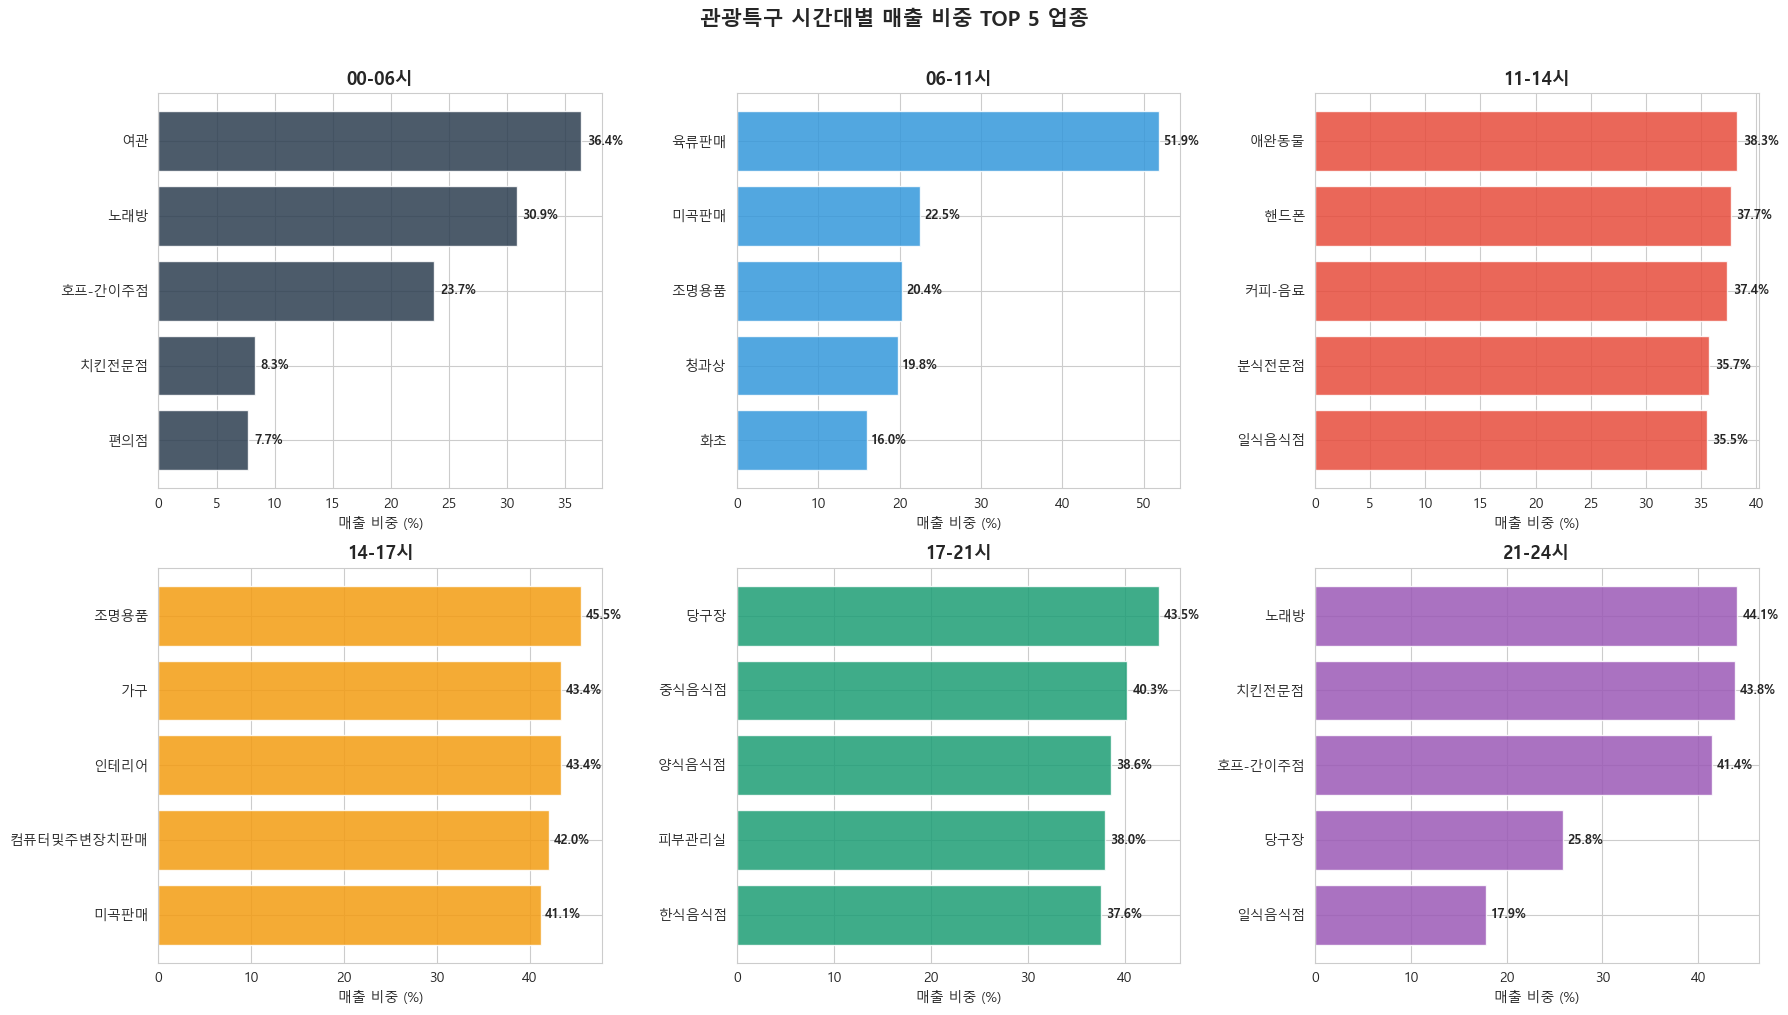

In [196]:
# %% 전체 관광특구 시간대별 TOP 5 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
시간색 = ['#2C3E50', '#3498DB', '#E74C3C', '#F39C12', '#1D9E75', '#9B59B6']
 
for idx, l in enumerate(시간라벨):
    ax = axes[idx]
    top5 = 관광전체.nlargest(5, f'비중_{l}')
 
    bars = ax.barh(range(len(top5)-1, -1, -1), top5[f'비중_{l}'].values,
                   color=시간색[idx], alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(top5)-1, -1, -1))
    ax.set_yticklabels(top5.index)
    ax.set_title(f'{l}시', fontsize=13, fontweight='bold')
    ax.set_xlabel('매출 비중 (%)')
 
    for bar, val in zip(bars, top5[f'비중_{l}'].values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
 
fig.suptitle('관광특구 시간대별 매출 비중 TOP 5 업종', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [197]:
# %% 상권별 시간대 편향 계산
결과_시간 = []
for 상권 in sorted(관광['상권_코드_명'].unique()):
    sub = 관광[관광['상권_코드_명'] == 상권]
    자치구 = sub['자치구_코드_명'].mode().iloc[0]
 
    업종 = sub.groupby('서비스_업종_코드_명')[시간_매출].sum()
    업종['총'] = 업종.sum(axis=1)
    업종 = 업종[업종['총'] > 업종['총'].quantile(0.3)]
    업종 = 업종[~업종.index.isin(제외_업종)]
 
    for i, l in enumerate(시간라벨):
        업종[f'비중_{l}'] = 업종[시간_매출[i]] / 업종['총'] * 100
 
    # 해당 상권 전체 평균 대비 편향
    for l in 시간라벨:
        전체평균 = 업종[f'비중_{l}'].mean()
        업종[f'편향_{l}'] = 업종[f'비중_{l}'] - 전체평균
 
    for name, row in 업종.iterrows():
        for l in 시간라벨:
            결과_시간.append({
                '상권': 상권, '자치구': 자치구, '업종': name,
                '시간대': l, '비중': row[f'비중_{l}'], '편향': row[f'편향_{l}']
            })
 
df_시간편향 = pd.DataFrame(결과_시간)

In [198]:
print('=' * 70)
for 상권 in sorted(df_시간편향['상권'].unique()):
    sub = df_시간편향[df_시간편향['상권'] == 상권]
    자치구 = sub['자치구'].iloc[0]
    print(f'\n▸ {상권} ({자치구})')
    for l in 시간라벨:
        시간sub = sub[sub['시간대'] == l].nlargest(3, '편향')
        print(f'  {l}: ', end='')
        for _, row in 시간sub.iterrows():
            print(f'{row["업종"]}({row["비중"]:.0f}%)', end='  ')
        print()


▸ 강남 마이스 관광특구 (강남구)
  00-06: 슈퍼마켓(3%)  화장품(1%)  중식음식점(0%)  
  06-11: 슈퍼마켓(18%)  화장품(15%)  커피-음료(15%)  
  11-14: 일식음식점(50%)  한식음식점(41%)  패스트푸드점(37%)  
  14-17: 가구(44%)  시계및귀금속(39%)  운동/경기용품(38%)  
  17-21: 양식음식점(43%)  중식음식점(42%)  일반의류(40%)  
  21-24: 슈퍼마켓(14%)  화장품(9%)  양식음식점(7%)  

▸ 동대문패션타운 관광특구 (중구)
  00-06: 여관(21%)  슈퍼마켓(20%)  중식음식점(19%)  
  06-11: 제과점(29%)  슈퍼마켓(17%)  철물점(17%)  
  11-14: 핸드폰(43%)  전자상거래업(37%)  철물점(34%)  
  14-17: 인테리어(46%)  가구(43%)  섬유제품(41%)  
  17-21: 일식음식점(50%)  안경(44%)  양식음식점(39%)  
  21-24: 치킨전문점(52%)  호프-간이주점(44%)  여관(24%)  

▸ 명동 남대문 북창동 다동 무교동 관광특구 (중구)
  00-06: 여관(44%)  호프-간이주점(8%)  치킨전문점(5%)  
  06-11: 육류판매(54%)  미곡판매(23%)  편의점(22%)  
  11-14: 분식전문점(48%)  애완동물(46%)  일식음식점(46%)  
  14-17: 인테리어(48%)  문구(44%)  운동/경기용품(43%)  
  17-21: 피부관리실(43%)  미용실(37%)  중식음식점(36%)  
  21-24: 호프-간이주점(50%)  치킨전문점(50%)  일식음식점(14%)  

▸ 이태원 관광특구 (용산구)
  00-06: 호프-간이주점(41%)  치킨전문점(26%)  패스트푸드점(21%)  
  06-11: 편의점(11%)  슈퍼마켓(10%)  제과점(9%)  
  11-14: 커피-음료(28%)  신발(28%)  미용실(27%

In [199]:
# %% 상권별 시간대 히트맵 (각 상권의 시간대별 1위 업종)
상권목록 = sorted(df_시간편향['상권'].unique())
 
print('\n📊 관광특구 상권별 시간대 1위 업종')
print(f'{"상권":<25}', end='')
for l in 시간라벨:
    print(f' {l:>14}', end='')
print()
print('-' * 115)
for 상권 in 상권목록:
    sub = df_시간편향[df_시간편향['상권'] == 상권]
    자치구 = sub['자치구'].iloc[0]
    print(f'{상권:<25}', end='')
    for l in 시간라벨:
        시간sub = sub[sub['시간대'] == l].nlargest(1, '편향')
        업종 = 시간sub['업종'].iloc[0]
        print(f' {업종:>14}', end='')
    print()


📊 관광특구 상권별 시간대 1위 업종
상권                                 00-06          06-11          11-14          14-17          17-21          21-24
-------------------------------------------------------------------------------------------------------------------
강남 마이스 관광특구                         슈퍼마켓           슈퍼마켓          일식음식점             가구          양식음식점           슈퍼마켓
동대문패션타운 관광특구                          여관            제과점            핸드폰           인테리어          일식음식점          치킨전문점
명동 남대문 북창동 다동 무교동 관광특구                여관           육류판매          분식전문점           인테리어          피부관리실        호프-간이주점
이태원 관광특구                         호프-간이주점            편의점          커피-음료             가방          중식음식점          치킨전문점
잠실 관광특구                              노래방           섬유제품          중식음식점             문구             신발        호프-간이주점
종로·청계 관광특구                            여관           인테리어          커피-음료           조명용품            당구장        호프-간이주점


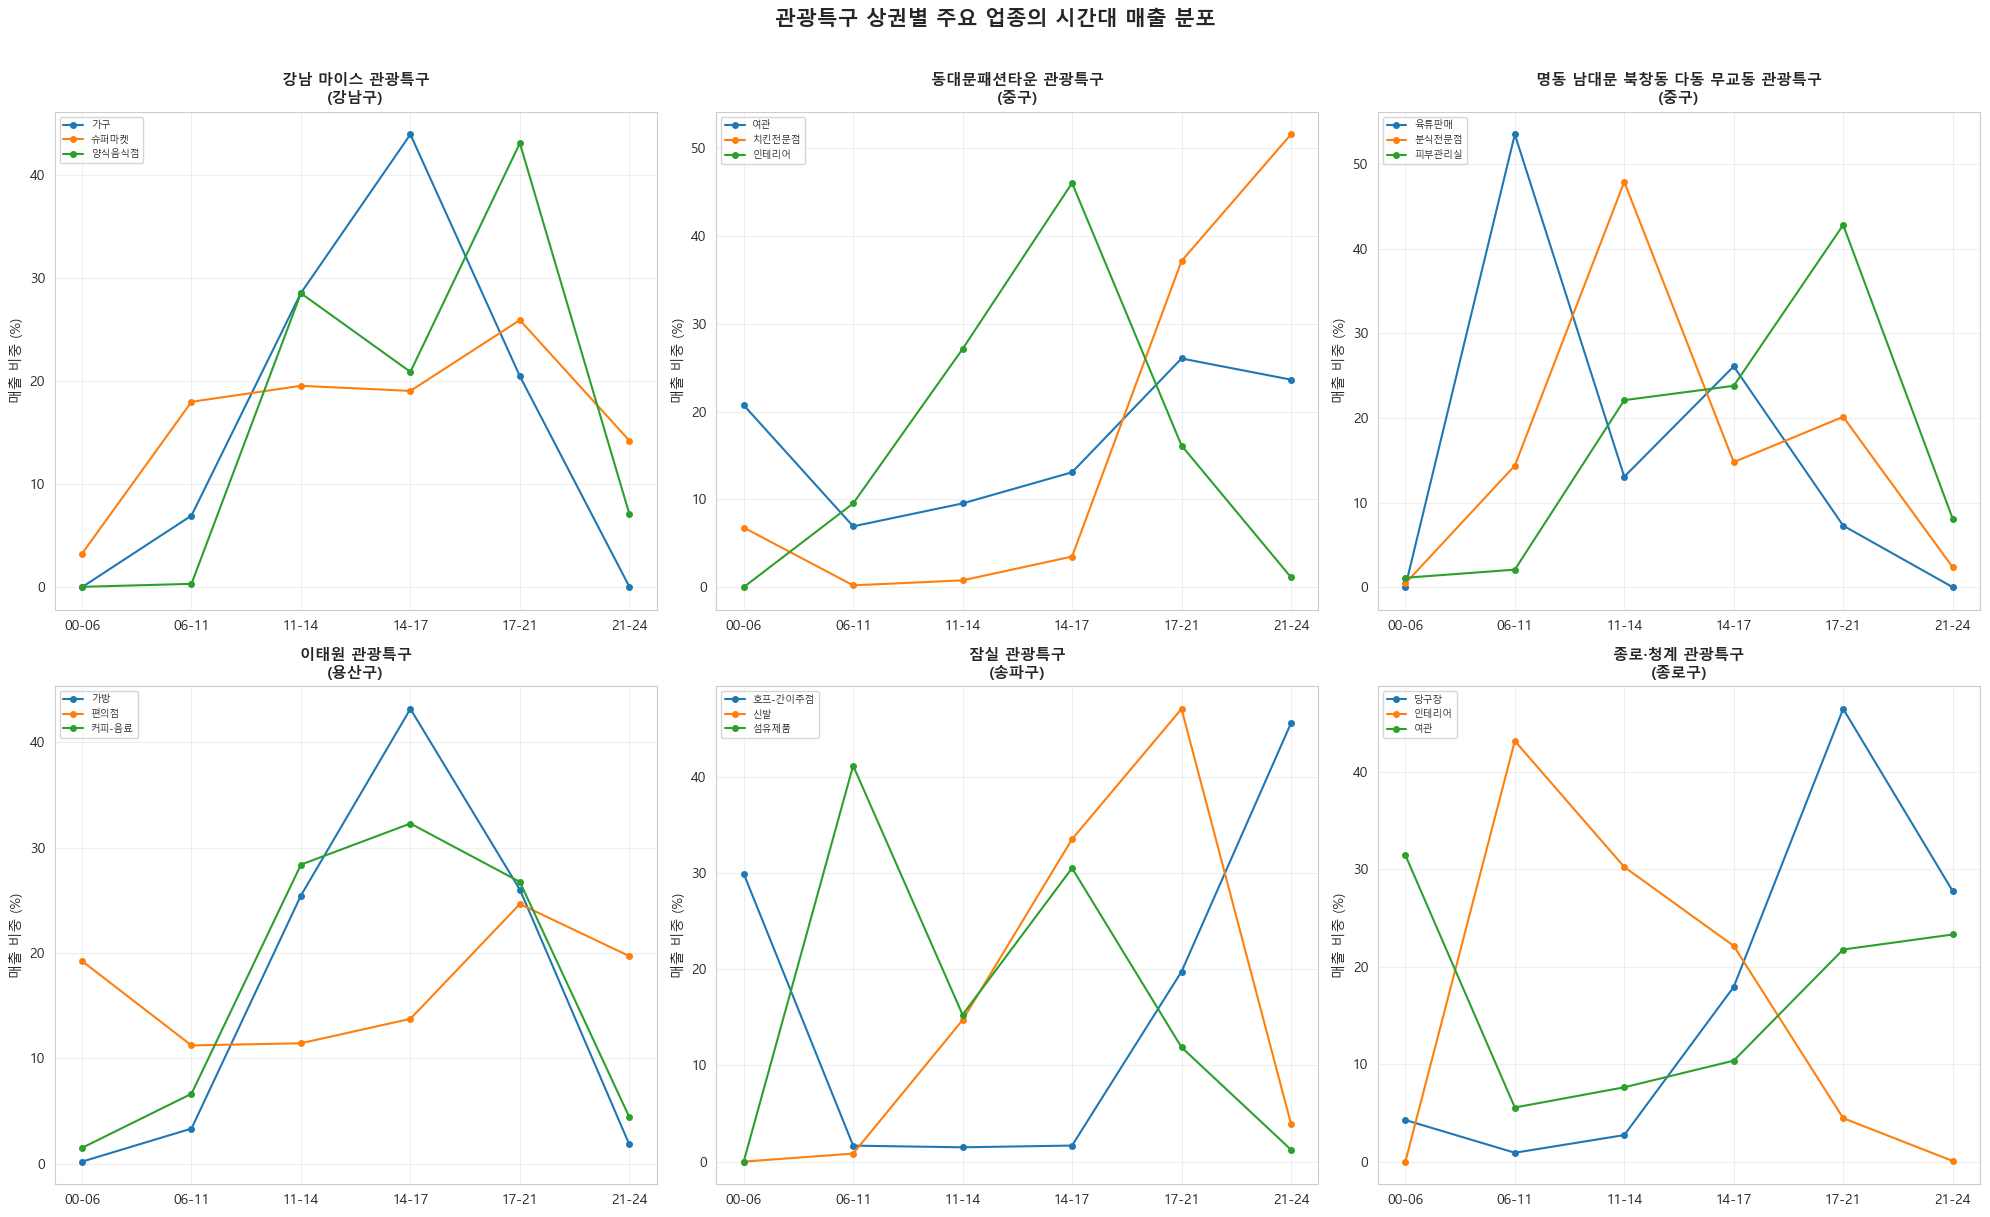

In [200]:
# %% 상권별 시간대 구조 시각화 (6개 상권 × 6개 시간대)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
 
for idx, 상권 in enumerate(상권목록):
    ax = axes[idx]
    sub = df_시간편향[df_시간편향['상권'] == 상권]
    자치구 = sub['자치구'].iloc[0]
 
    top_업종들 = set()
    for l in 시간라벨:
        시간sub = sub[sub['시간대'] == l].nlargest(1, '편향')
        top_업종들.update(시간sub['업종'].tolist())

    # 그중 편향 합계 기준 TOP 3만 선택
    업종_편향합 = sub.groupby('업종')['편향'].sum()
    업종_편향합 = 업종_편향합[업종_편향합.index.isin(top_업종들)]
    최종업종 = 업종_편향합.nlargest(3).index.tolist()

    for 업종 in 최종업종:
 
    # 선택된 업종들의 시간대별 비중을 꺾은선으로  # 최대 6개
        업종_data = sub[sub['업종'] == 업종].sort_values('시간대')
        if len(업종_data) == 6:
            ax.plot(업종_data['시간대'].values, 업종_data['비중'].values,
                    marker='o', markersize=4, linewidth=1.5, label=업종)
 
    ax.set_title(f'{상권}\n({자치구})', fontsize=11, fontweight='bold')
    ax.set_ylabel('매출 비중 (%)')
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(alpha=0.3)
 
fig.suptitle('관광특구 상권별 주요 업종의 시간대 매출 분포', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**피드백**: 커피·주점·화장품을 시간/요일/성별로 엮어서 더 세밀하게 분석

In [201]:
# %% 데이터 준비
타겟업종 = ['커피-음료', '호프-간이주점', '화장품']
시간_매출 = ['시간대_00~06_매출_금액', '시간대_06~11_매출_금액', '시간대_11~14_매출_금액',
           '시간대_14~17_매출_금액', '시간대_17~21_매출_금액', '시간대_21~24_매출_금액']
시간라벨 = ['00-06', '06-11', '11-14', '14-17', '17-21', '21-24']
 
floating['2030_비율'] = (
    floating['연령대_20_유동인구_수'] + floating['연령대_30_유동인구_수']
) / floating['총_유동인구_수'].replace(0, np.nan) * 100
 
타겟_sales = sales[sales['서비스_업종_코드_명'].isin(타겟업종)].copy()

In [202]:
# %% 성별 분석
성별_타겟 = 타겟_sales.groupby(
    ['기준_년분기_코드', '상권_코드', '서비스_업종_코드_명']
).agg(남성=('남성_매출_금액', 'sum'), 여성=('여성_매출_금액', 'sum'), 총=('당월_매출_금액', 'sum')).reset_index()
 
성별_타겟 = 성별_타겟.merge(
    floating[['기준_년분기_코드', '상권_코드', '2030_비율']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)
성별_타겟['여성비율'] = 성별_타겟['여성'] / 성별_타겟['총'].replace(0, np.nan) * 100
성별_타겟['남성비율'] = 성별_타겟['남성'] / 성별_타겟['총'].replace(0, np.nan) * 100
성별_타겟['2030_구간'] = pd.qcut(
    성별_타겟['2030_비율'].dropna(), q=3,
    labels=['2030 낮음', '2030 중간', '2030 높음'], duplicates='drop'
)

In [203]:
# 💡 여성과 남성 매출 비율을 동시에 비교하는 코드

print('📊 2030 구간 × 업종 × 성별 매출 비율')
print(f'{"업종":<15} {"2030 구간":<12} {"여성매출비율":>12} {"남성매출비율":>12}') 
print('-' * 60) 

for 업종 in 타겟업종:
    for 구간 in ['2030 낮음', '2030 중간', '2030 높음']:
        # 다중 조건으로 데이터 필터링
        sub = 성별_타겟[(성별_타겟['서비스_업종_코드_명'] == 업종) & (성별_타겟['2030_구간'] == 구간)]
        
        # 가독성을 위해 변수로 먼저 할당
        여성_평균 = sub["여성비율"].mean()
        남성_평균 = sub["남성비율"].mean()
        
        # 여성과 남성 비율을 나란히 출력
        print(f'{업종:<15} {구간:<12} {여성_평균:>11.1f}% {남성_평균:>11.1f}%')

📊 2030 구간 × 업종 × 성별 매출 비율
업종              2030 구간            여성매출비율       남성매출비율
------------------------------------------------------------
커피-음료           2030 낮음             51.2%        43.4%
커피-음료           2030 중간             49.4%        42.5%
커피-음료           2030 높음             48.9%        40.6%
호프-간이주점         2030 낮음             25.8%        68.8%
호프-간이주점         2030 중간             28.2%        64.2%
호프-간이주점         2030 높음             30.7%        57.4%
화장품             2030 낮음             70.2%        28.4%
화장품             2030 중간             68.9%        29.5%
화장품             2030 높음             61.7%        35.0%


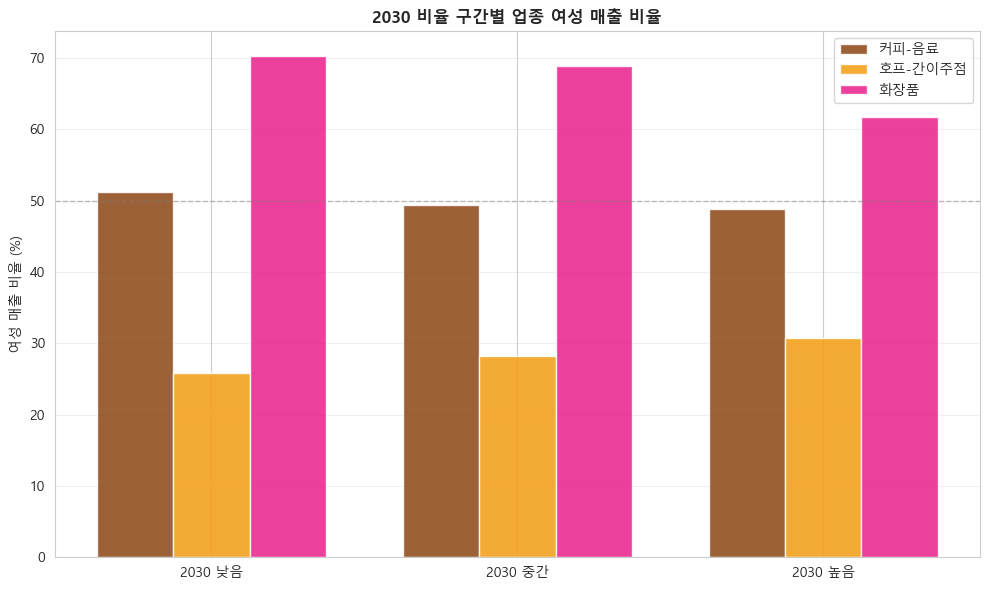

In [204]:
성별결과 = 성별_타겟.groupby(['서비스_업종_코드_명', '2030_구간'])['여성비율'].mean().reset_index()
 
fig, ax = plt.subplots(figsize=(10, 6))
업종색 = {'커피-음료': '#8B4513', '호프-간이주점': '#F39C12', '화장품': '#E91E8C'}
x = np.arange(3)
w = 0.25
 
for i, 업종 in enumerate(타겟업종):
    sub = 성별결과[성별결과['서비스_업종_코드_명'] == 업종]
    ax.bar(x + i*w - w, sub['여성비율'].values, w, color=업종색[업종], alpha=0.85, label=업종)
 
ax.set_xticks(x)
ax.set_xticklabels(['2030 낮음', '2030 중간', '2030 높음'])
ax.set_ylabel('여성 매출 비율 (%)')
ax.set_title('2030 비율 구간별 업종 여성 매출 비율', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()

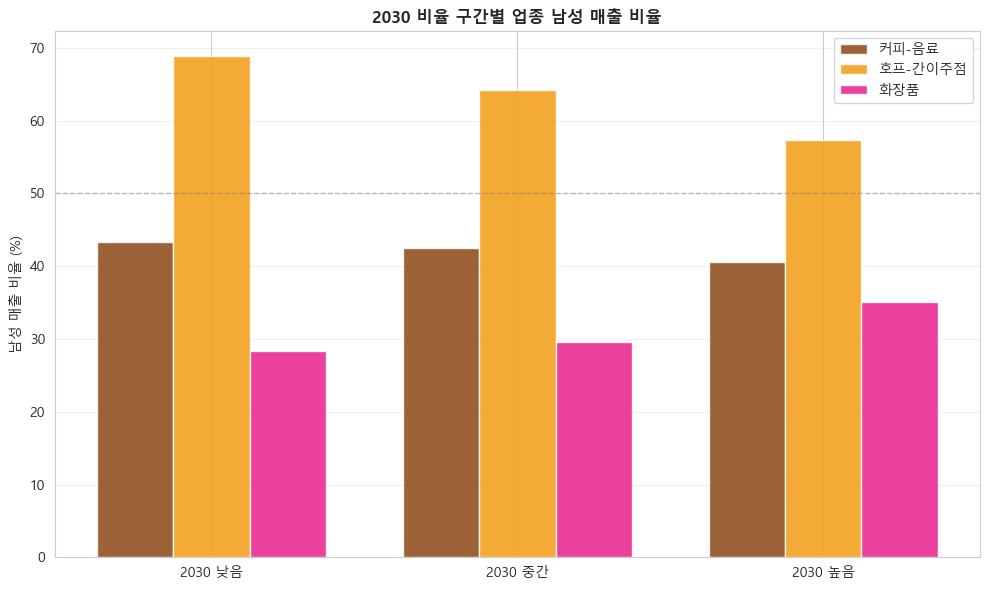

In [205]:
성별결과_남성 = 성별_타겟.groupby(['서비스_업종_코드_명', '2030_구간'])['남성비율'].mean().reset_index()
 
fig, ax = plt.subplots(figsize=(10, 6))
업종색 = {'커피-음료': '#8B4513', '호프-간이주점': '#F39C12', '화장품': '#E91E8C'}
x = np.arange(3)
w = 0.25 # 막대 너비
 
for i, 업종 in enumerate(타겟업종):
    sub = 성별결과_남성[성별결과_남성['서비스_업종_코드_명'] == 업종]
    # x 위치를 조정하여 막대가 겹치지 않도록 배치
    ax.bar(x + i*w - w, sub['남성비율'].values, w, color=업종색[업종], alpha=0.85, label=업종)

ax.set_xticks(x)
ax.set_xticklabels(['2030 낮음', '2030 중간', '2030 높음'])
ax.set_ylabel('남성 매출 비율 (%)') # 라벨 수정
ax.set_title('2030 비율 구간별 업종 남성 매출 비율', fontweight='bold') # 제목 수정
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5) 

plt.tight_layout()
plt.show()

In [206]:
# %% 시간대 분석
시간_타겟 = 타겟_sales.groupby(
    ['기준_년분기_코드', '상권_코드', '서비스_업종_코드_명']
)[시간_매출 + ['당월_매출_금액']].sum().reset_index()
 
시간_타겟 = 시간_타겟.merge(
    floating[['기준_년분기_코드', '상권_코드', '2030_비율']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)
시간_타겟['2030_구간'] = pd.qcut(
    시간_타겟['2030_비율'].dropna(), q=3,
    labels=['2030 낮음', '2030 중간', '2030 높음'], duplicates='drop'
)

In [207]:
print('\n📊 2030 구간 × 업종 × 시간대 매출 비중')
for 업종 in 타겟업종:
    print(f'\n▸ {업종}')
    print(f'  {"구간":<12}', end='')
    for l in 시간라벨:
        print(f' {l:>7}', end='')
    print()
    for 구간 in ['2030 낮음', '2030 중간', '2030 높음']:
        sub = 시간_타겟[(시간_타겟['서비스_업종_코드_명'] == 업종) & (시간_타겟['2030_구간'] == 구간)]
        print(f'  {구간:<12}', end='')
        for col in 시간_매출:
            비중 = (sub[col] / sub['당월_매출_금액'].replace(0, np.nan) * 100).mean()
            print(f' {비중:>6.1f}%', end='')
        print()


📊 2030 구간 × 업종 × 시간대 매출 비중

▸ 커피-음료
  구간             00-06   06-11   11-14   14-17   17-21   21-24
  2030 낮음         0.4%   12.4%   33.3%   29.2%   21.0%    3.8%
  2030 중간         0.5%   12.7%   33.9%   27.0%   21.6%    4.3%
  2030 높음         0.8%   12.7%   34.6%   25.5%   21.7%    4.7%

▸ 호프-간이주점
  구간             00-06   06-11   11-14   14-17   17-21   21-24
  2030 낮음        17.2%    1.1%    3.6%    5.4%   31.5%   41.2%
  2030 중간        18.4%    0.9%    3.5%    3.8%   29.5%   43.9%
  2030 높음        20.5%    1.2%    5.5%    3.2%   25.5%   44.2%

▸ 화장품
  구간             00-06   06-11   11-14   14-17   17-21   21-24
  2030 낮음         1.1%    6.9%   26.2%   32.2%   29.7%    3.9%
  2030 중간         1.8%    6.6%   25.9%   32.9%   28.2%    4.6%
  2030 높음         2.4%    7.4%   24.1%   31.5%   28.4%    6.2%


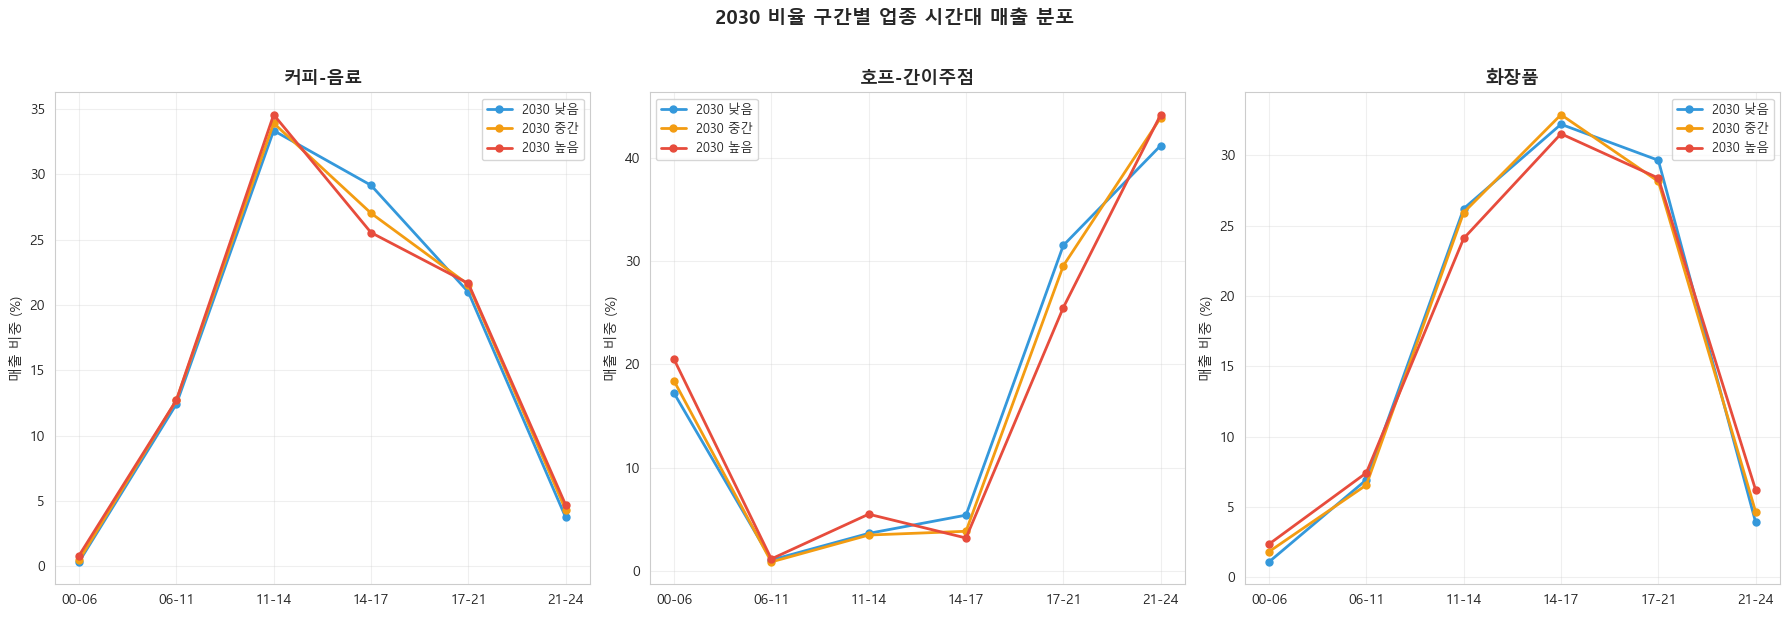

In [208]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
 
for idx, 업종 in enumerate(타겟업종):
    ax = axes[idx]
    구간색 = {'2030 낮음': '#3498DB', '2030 중간': '#F39C12', '2030 높음': '#E74C3C'}
 
    for 구간 in ['2030 낮음', '2030 중간', '2030 높음']:
        sub = 시간_타겟[(시간_타겟['서비스_업종_코드_명'] == 업종) & (시간_타겟['2030_구간'] == 구간)]
        비중 = [(sub[col] / sub['당월_매출_금액'].replace(0, np.nan) * 100).mean() for col in 시간_매출]
        ax.plot(시간라벨, 비중, marker='o', markersize=5, linewidth=2,
                color=구간색[구간], label=구간)
 
    ax.set_title(업종, fontweight='bold', fontsize=13)
    ax.set_ylabel('매출 비중 (%)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
 
fig.suptitle('2030 비율 구간별 업종 시간대 매출 분포', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [209]:
# %% 요일 분석
요일_타겟 = 타겟_sales.groupby(
    ['기준_년분기_코드', '상권_코드', '서비스_업종_코드_명']
)[요일_매출 + ['당월_매출_금액']].sum().reset_index()
 
요일_타겟 = 요일_타겟.merge(
    floating[['기준_년분기_코드', '상권_코드', '2030_비율']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)
요일_타겟['2030_구간'] = pd.qcut(
    요일_타겟['2030_비율'].dropna(), q=3,
    labels=['2030 낮음', '2030 중간', '2030 높음'], duplicates='drop'
)

In [210]:
print('\n📊 2030 구간 × 업종 × 요일 매출 비중')
for 업종 in 타겟업종:
    print(f'\n▸ {업종}')
    print(f'  {"구간":<12}', end='')
    for l in 요일라벨:
        print(f' {l:>6}', end='')
    print()
    for 구간 in ['2030 낮음', '2030 중간', '2030 높음']:
        sub = 요일_타겟[(요일_타겟['서비스_업종_코드_명'] == 업종) & (요일_타겟['2030_구간'] == 구간)]
        print(f'  {구간:<12}', end='')
        for col in 요일_매출:
            비중 = (sub[col] / sub['당월_매출_금액'].replace(0, np.nan) * 100).mean()
            print(f' {비중:>5.1f}%', end='')
        print()


📊 2030 구간 × 업종 × 요일 매출 비중

▸ 커피-음료
  구간                월      화      수      목      금      토      일
  2030 낮음       12.6%  13.9%  14.2%  14.2%  15.0%  15.9%  14.2%
  2030 중간       12.9%  14.0%  14.6%  14.6%  15.4%  15.3%  13.1%
  2030 높음       13.7%  14.5%  15.1%  15.2%  15.8%  14.1%  11.6%

▸ 호프-간이주점
  구간                월      화      수      목      금      토      일
  2030 낮음       11.8%  13.1%  13.8%  13.7%  16.3%  18.6%  12.8%
  2030 중간       11.7%  13.5%  14.0%  14.3%  16.8%  18.0%  11.6%
  2030 높음       11.5%  13.7%  14.3%  14.9%  17.5%  17.5%  10.7%

▸ 화장품
  구간                월      화      수      목      금      토      일
  2030 낮음       15.5%  15.7%  16.8%  16.2%  16.3%  13.3%   6.2%
  2030 중간       15.8%  17.0%  16.0%  16.6%  16.5%  12.2%   5.9%
  2030 높음       14.8%  15.5%  16.2%  16.3%  17.4%  12.8%   7.0%


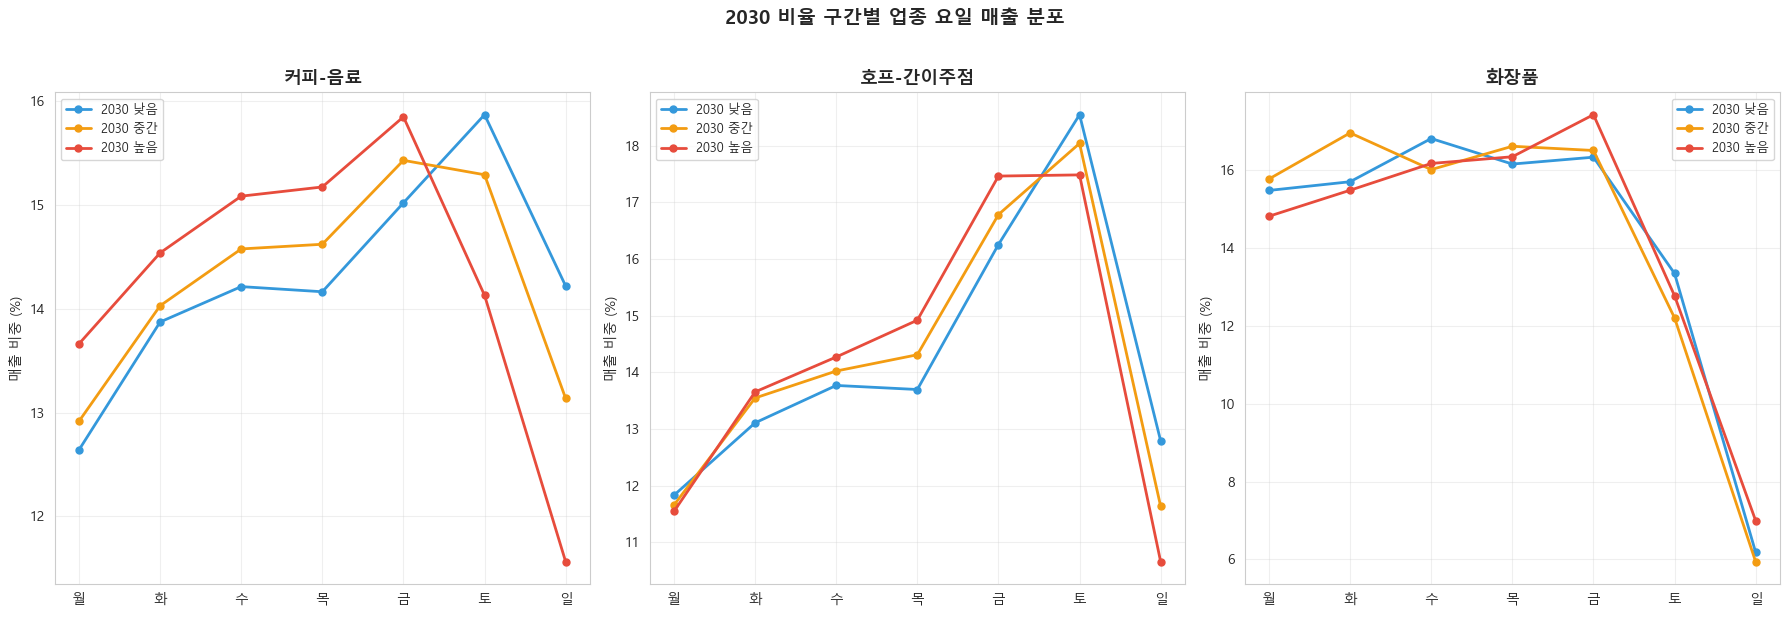

In [211]:
# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
 
for idx, 업종 in enumerate(타겟업종):
    ax = axes[idx]
    구간색 = {'2030 낮음': '#3498DB', '2030 중간': '#F39C12', '2030 높음': '#E74C3C'}
 
    for 구간 in ['2030 낮음', '2030 중간', '2030 높음']:
        sub = 요일_타겟[(요일_타겟['서비스_업종_코드_명'] == 업종) & (요일_타겟['2030_구간'] == 구간)]
        비중 = [(sub[col] / sub['당월_매출_금액'].replace(0, np.nan) * 100).mean() for col in 요일_매출]
        ax.plot(요일라벨, 비중, marker='o', markersize=5, linewidth=2,
                color=구간색[구간], label=구간)
 
    ax.set_title(업종, fontweight='bold', fontsize=13)
    ax.set_ylabel('매출 비중 (%)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
 
fig.suptitle('2030 비율 구간별 업종 요일 매출 분포', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**목표**: 남성/여성 각각 매출 비율이 높은 업종은 무엇이고, 시간대·요일 패턴이 어떻게 다른지

In [212]:
# %% 컬럼 정의
시간_매출 = ['시간대_00~06_매출_금액', '시간대_06~11_매출_금액', '시간대_11~14_매출_금액',
           '시간대_14~17_매출_금액', '시간대_17~21_매출_금액', '시간대_21~24_매출_금액']
시간라벨 = ['00-06', '06-11', '11-14', '14-17', '17-21', '21-24']
 
요일_매출 = ['월요일_매출_금액', '화요일_매출_금액', '수요일_매출_금액', '목요일_매출_금액',
           '금요일_매출_금액', '토요일_매출_금액', '일요일_매출_금액']
요일라벨 = ['월', '화', '수', '목', '금', '토', '일']

In [213]:
# %% 업종별 성별 매출 비율
업종성별 = sales.groupby('서비스_업종_코드_명').agg(
    남성=('남성_매출_금액', 'sum'), 여성=('여성_매출_금액', 'sum'), 총=('당월_매출_금액', 'sum')
).reset_index()
업종성별['남성비율'] = 업종성별['남성'] / 업종성별['총'] * 100
업종성별['여성비율'] = 업종성별['여성'] / 업종성별['총'] * 100

In [214]:
# 매출 하위 10% 제외
업종성별 = 업종성별[업종성별['총'] > 업종성별['총'].quantile(0.1)]
 
# TOP 5 추출
남성TOP = 업종성별.nlargest(5, '남성비율')['서비스_업종_코드_명'].tolist()
여성TOP = 업종성별.nlargest(5, '여성비율')['서비스_업종_코드_명'].tolist()

In [215]:
print('📊 남성 매출 비율 TOP 5')
print('-' * 45)
for _, row in 업종성별.nlargest(5, '남성비율').iterrows():
    print(f'  {row["서비스_업종_코드_명"]:<15} 남성 {row["남성비율"]:.1f}% | 여성 {row["여성비율"]:.1f}%')
 
print('\n📊 여성 매출 비율 TOP 5')
print('-' * 45)
for _, row in 업종성별.nlargest(5, '여성비율').iterrows():
    print(f'  {row["서비스_업종_코드_명"]:<15} 여성 {row["여성비율"]:.1f}% | 남성 {row["남성비율"]:.1f}%')

📊 남성 매출 비율 TOP 5
---------------------------------------------
  PC방             남성 80.8% | 여성 19.1%
  당구장             남성 76.1% | 여성 20.7%
  노래방             남성 73.1% | 여성 18.7%
  의료기기            남성 70.2% | 여성 24.5%
  골프연습장           남성 66.6% | 여성 21.1%

📊 여성 매출 비율 TOP 5
---------------------------------------------
  피부관리실           여성 72.3% | 남성 24.2%
  화장품             여성 63.9% | 남성 31.8%
  가방              여성 63.7% | 남성 33.0%
  일반의원            여성 62.8% | 남성 37.0%
  한의원             여성 62.7% | 남성 36.5%


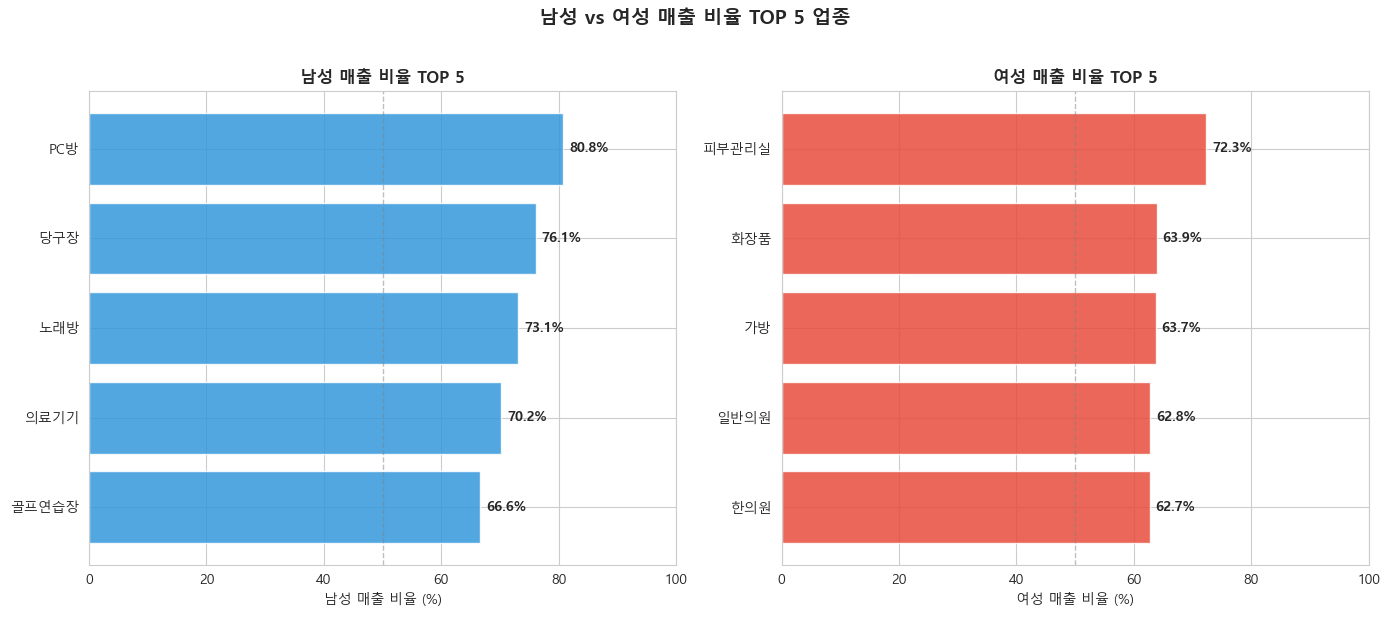

In [216]:
# %% 남성 vs 여성 TOP 5 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# (1) 남성 TOP 5
ax1 = axes[0]
남성data = 업종성별.nlargest(5, '남성비율').sort_values('남성비율')
ax1.barh(남성data['서비스_업종_코드_명'], 남성data['남성비율'], color='#3498DB', alpha=0.85, edgecolor='white')
ax1.set_xlabel('남성 매출 비율 (%)')
ax1.set_title('남성 매출 비율 TOP 5', fontweight='bold')
ax1.set_xlim(0, 100)
ax1.axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
for i, (_, row) in enumerate(남성data.iterrows()):
    ax1.text(row['남성비율'] + 1, i, f'{row["남성비율"]:.1f}%', va='center', fontweight='bold')
 
# (2) 여성 TOP 5
ax2 = axes[1]
여성data = 업종성별.nlargest(5, '여성비율').sort_values('여성비율')
ax2.barh(여성data['서비스_업종_코드_명'], 여성data['여성비율'], color='#E74C3C', alpha=0.85, edgecolor='white')
ax2.set_xlabel('여성 매출 비율 (%)')
ax2.set_title('여성 매출 비율 TOP 5', fontweight='bold')
ax2.set_xlim(0, 100)
ax2.axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
for i, (_, row) in enumerate(여성data.iterrows()):
    ax2.text(row['여성비율'] + 1, i, f'{row["여성비율"]:.1f}%', va='center', fontweight='bold')
 
plt.suptitle('남성 vs 여성 매출 비율 TOP 5 업종', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [217]:
# %% 시간대별 매출 비중 계산
남성_시간 = sales[sales['서비스_업종_코드_명'].isin(남성TOP)].groupby(
    '서비스_업종_코드_명'
)[시간_매출 + ['당월_매출_금액']].sum()
 
여성_시간 = sales[sales['서비스_업종_코드_명'].isin(여성TOP)].groupby(
    '서비스_업종_코드_명'
)[시간_매출 + ['당월_매출_금액']].sum()
 
# 출력
print('📊 남성 TOP 5 시간대별 매출 비중')
print(f'{"업종":<15}', end='')
for l in 시간라벨:
    print(f' {l:>7}', end='')
print()
print('-' * 60)
for 업종 in 남성TOP:
    row = 남성_시간.loc[업종]
    print(f'{업종:<15}', end='')
    for col in 시간_매출:
        print(f' {row[col]/row["당월_매출_금액"]*100:>6.1f}%', end='')
    print()

📊 남성 TOP 5 시간대별 매출 비중
업종                00-06   06-11   11-14   14-17   17-21   21-24
------------------------------------------------------------
PC방               13.3%    6.3%   12.3%   19.3%   31.2%   17.6%
당구장                6.4%    3.5%    8.1%   16.6%   41.9%   23.5%
노래방               35.8%    1.6%    1.0%    3.1%   19.0%   39.5%
의료기기               0.0%   16.5%   37.7%   39.2%    6.5%    0.2%
골프연습장              4.0%    6.7%   15.1%   19.8%   35.6%   18.7%


In [218]:
print(f'\n📊 여성 TOP 5 시간대별 매출 비중')
print(f'{"업종":<15}', end='')
for l in 시간라벨:
    print(f' {l:>7}', end='')
print()
print('-' * 60)
for 업종 in 여성TOP:
    row = 여성_시간.loc[업종]
    print(f'{업종:<15}', end='')
    for col in 시간_매출:
        print(f' {row[col]/row["당월_매출_금액"]*100:>6.1f}%', end='')
    print()


📊 여성 TOP 5 시간대별 매출 비중
업종                00-06   06-11   11-14   14-17   17-21   21-24
------------------------------------------------------------
피부관리실              1.0%    4.3%   22.7%   28.9%   35.7%    7.3%
화장품                0.7%    8.2%   26.2%   31.4%   28.0%    5.5%
가방                 0.1%    2.5%   23.7%   35.7%   34.9%    3.3%
일반의원               0.0%   21.3%   31.8%   30.1%   16.7%    0.1%
한의원                0.0%   11.9%   35.9%   30.2%   21.7%    0.2%


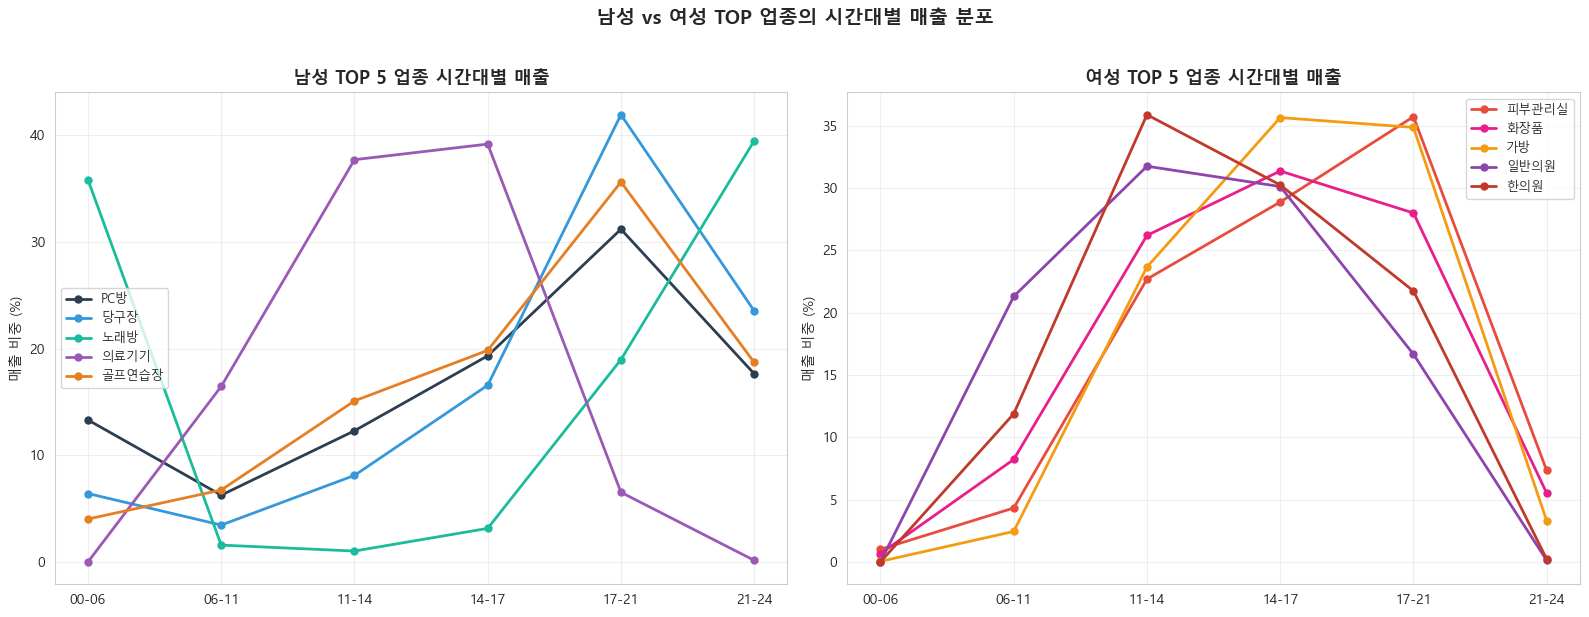

In [219]:
# %% 시간대 꺾은선 시각화: 남성 vs 여성
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# (1) 남성 TOP 5
ax1 = axes[0]
남성색 = ['#2C3E50', '#3498DB', '#1ABC9C', '#9B59B6', '#E67E22']
for i, 업종 in enumerate(남성TOP):
    row = 남성_시간.loc[업종]
    비중 = [row[col] / row['당월_매출_금액'] * 100 for col in 시간_매출]
    ax1.plot(시간라벨, 비중, marker='o', markersize=5, linewidth=2,
             color=남성색[i], label=업종)
ax1.set_title('남성 TOP 5 업종 시간대별 매출', fontweight='bold', fontsize=13)
ax1.set_ylabel('매출 비중 (%)')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
 
# (2) 여성 TOP 5
ax2 = axes[1]
여성색 = ['#E74C3C', '#E91E8C', '#F39C12', '#8E44AD', '#C0392B']
for i, 업종 in enumerate(여성TOP):
    row = 여성_시간.loc[업종]
    비중 = [row[col] / row['당월_매출_금액'] * 100 for col in 시간_매출]
    ax2.plot(시간라벨, 비중, marker='o', markersize=5, linewidth=2,
             color=여성색[i], label=업종)
ax2.set_title('여성 TOP 5 업종 시간대별 매출', fontweight='bold', fontsize=13)
ax2.set_ylabel('매출 비중 (%)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
 
plt.suptitle('남성 vs 여성 TOP 업종의 시간대별 매출 분포', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [220]:
# %% 요일별 매출 비중
남성_요일 = sales[sales['서비스_업종_코드_명'].isin(남성TOP)].groupby(
    '서비스_업종_코드_명'
)[요일_매출 + ['당월_매출_금액']].sum()
 
여성_요일 = sales[sales['서비스_업종_코드_명'].isin(여성TOP)].groupby(
    '서비스_업종_코드_명'
)[요일_매출 + ['당월_매출_금액']].sum()

In [221]:
# 출력
print('📊 남성 TOP 5 요일별 매출 비중')
print(f'{"업종":<15}', end='')
for l in 요일라벨:
    print(f' {l:>6}', end='')
print()
print('-' * 60)
for 업종 in 남성TOP:
    row = 남성_요일.loc[업종]
    print(f'{업종:<15}', end='')
    for col in 요일_매출:
        print(f' {row[col]/row["당월_매출_금액"]*100:>5.1f}%', end='')
    print()

📊 남성 TOP 5 요일별 매출 비중
업종                   월      화      수      목      금      토      일
------------------------------------------------------------
PC방              12.6%  12.2%  12.5%  12.7%  14.6%  18.4%  17.0%
당구장              13.5%  14.0%  13.9%  14.2%  14.9%  16.9%  12.6%
노래방              10.2%  12.9%  13.2%  13.6%  16.1%  20.0%  14.0%
의료기기             17.5%  20.3%  18.2%  17.9%  21.0%   4.2%   0.9%
골프연습장            14.5%  14.1%  13.6%  13.3%  13.8%  16.1%  14.7%


In [222]:
# 💡 여성 TOP 5 업종 요일별 매출 비중 출력 코드

print('\n📊 여성 TOP 5 요일별 매출 비중')
# 1. 헤더 출력
print(f'{"업종":<15}', end='')
for l in 요일라벨:
    print(f' {l:>6}', end='')
print()
print('-' * 60)

# 2. 데이터 출력
for 업종 in 여성TOP:
    # 여성_요일 데이터프레임에서 해당 업종의 행(row) 데이터만 추출
    row = 여성_요일.loc[업종]
    
    print(f'{업종:<15}', end='')
    for col in 요일_매출:
        # 비중 계산 및 출력 (소수점 1자리 + % 기호)
        비중 = row[col] / row["당월_매출_금액"] * 100
        print(f' {비중:>5.1f}%', end='')
    print() # 한 업종의 요일 출력이 끝나면 줄바꿈


📊 여성 TOP 5 요일별 매출 비중
업종                   월      화      수      목      금      토      일
------------------------------------------------------------
피부관리실            14.7%  15.0%  15.5%  15.7%  17.3%  16.7%   5.2%
화장품              15.3%  16.2%  15.9%  16.3%  17.0%  11.6%   7.8%
가방               12.4%  12.5%  13.6%  13.0%  14.5%  18.8%  15.2%
일반의원             18.3%  17.0%  14.3%  15.5%  19.2%  15.0%   0.7%
한의원              18.7%  16.7%  14.4%  13.8%  17.4%  17.5%   1.6%


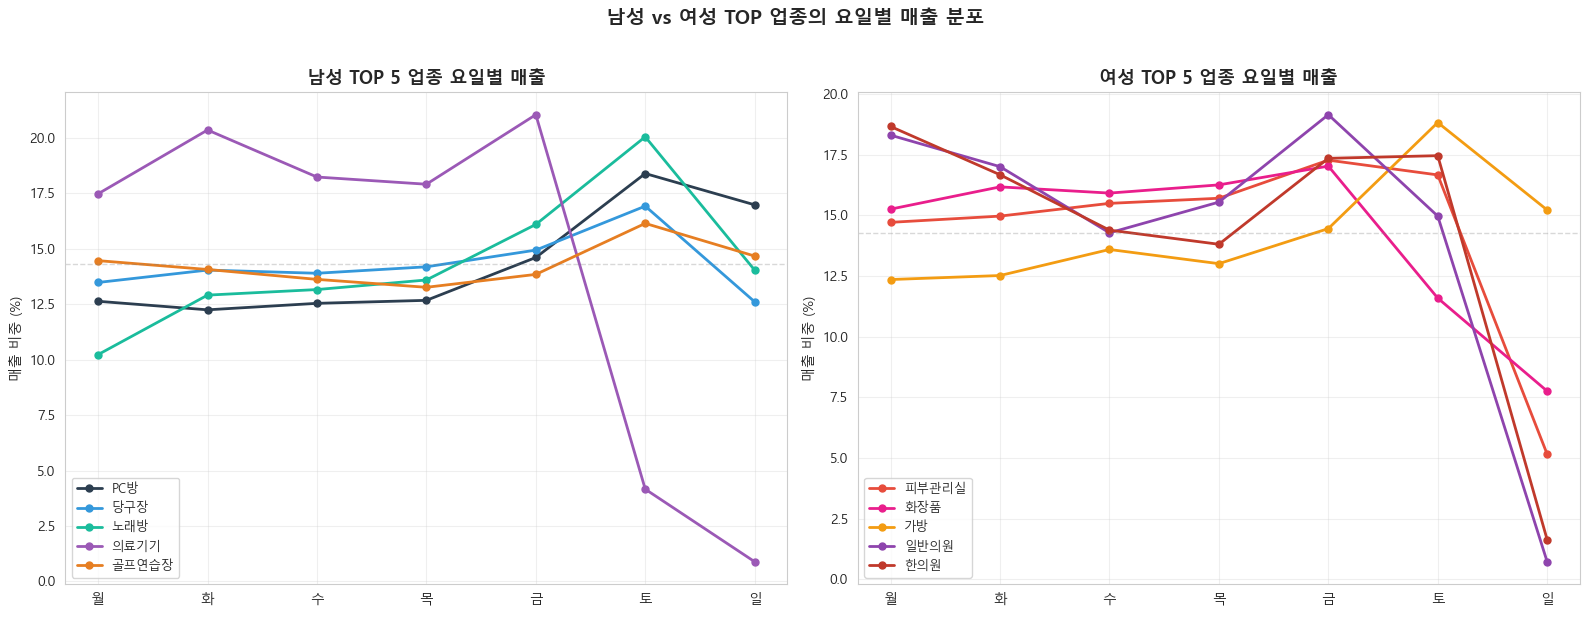

In [223]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# (1) 남성 TOP 5 요일
ax1 = axes[0]
for i, 업종 in enumerate(남성TOP):
    row = 남성_요일.loc[업종]
    비중 = [row[col] / row['당월_매출_금액'] * 100 for col in 요일_매출]
    ax1.plot(요일라벨, 비중, marker='o', markersize=5, linewidth=2,
             color=남성색[i], label=업종)
ax1.set_title('남성 TOP 5 업종 요일별 매출', fontweight='bold', fontsize=13)
ax1.set_ylabel('매출 비중 (%)')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.axhline(100/7, color='gray', linestyle='--', linewidth=1, alpha=0.3)
 
# (2) 여성 TOP 5 요일
ax2 = axes[1]
for i, 업종 in enumerate(여성TOP):
    row = 여성_요일.loc[업종]
    비중 = [row[col] / row['당월_매출_금액'] * 100 for col in 요일_매출]
    ax2.plot(요일라벨, 비중, marker='o', markersize=5, linewidth=2,
             color=여성색[i], label=업종)
ax2.set_title('여성 TOP 5 업종 요일별 매출', fontweight='bold', fontsize=13)
ax2.set_ylabel('매출 비중 (%)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.axhline(100/7, color='gray', linestyle='--', linewidth=1, alpha=0.3)
 
plt.suptitle('남성 vs 여성 TOP 업종의 요일별 매출 분포', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [224]:
# 💡 1. 5060 주력 업종 추출 및 성별 분리

# 50대, 60대 이상 매출을 합산하여 '5060_총매출' 파생변수 생성 (컬럼명은 실제 데이터에 맞게 수정)
sales['5060_총매출'] = sales['연령대_50_매출_금액'] + sales['연령대_60_이상_매출_금액']

# 업종별 5060 총매출 집계 및 TOP 3 추출
업종_5060 = sales.groupby('서비스_업종_코드_명')['5060_총매출'].sum().reset_index()
top3_5060_업종 = 업종_5060.nlargest(3, '5060_총매출')['서비스_업종_코드_명'].tolist()
print(f"✅ 5060 타겟 TOP 3 업종: {top3_5060_업종}")

# TOP 3 업종에 대한 성별 및 연령대 매출 데이터셋 세팅
# (남성_매출_금액, 여성_매출_금액 등은 기존 sales 데이터에 있다고 가정)
타겟_sales_5060 = sales[sales['서비스_업종_코드_명'].isin(top3_5060_업종)]
성별_5060 = 타겟_sales_5060.groupby(['기준_년분기_코드', '상권_코드', '서비스_업종_코드_명']).agg(
    남성=('남성_매출_금액', 'sum'), 
    여성=('여성_매출_금액', 'sum'), 
    총매출=('당월_매출_금액', 'sum'),
    시니어매출=('5060_총매출', 'sum')
).reset_index()

# 전체 매출 대비 5060 타겟 업종의 매출 비중 계산
성별_5060['타겟업종_비중'] = 성별_5060['시니어매출'] / 성별_5060['총매출'].replace(0, np.nan) * 100

✅ 5060 타겟 TOP 3 업종: ['한식음식점', '일반의류', '의약품']


In [225]:
# %% 5060 상주인구 기반 상권 유형별 상관계수 분석 통합 코드

# 1. 5060 상주인구 비율 생성 ('df_상주' 변수명 적용)
df_상주['5060_상주_비율'] = (df_상주['연령대_50_상주인구_수'].fillna(0) + df_상주['연령대_60_이상_상주인구_수'].fillna(0)) / df_상주['총_상주인구_수'].replace(0, np.nan) * 100

# 2. 상권별 당월 총매출 집계 (sales 활용)
총매출_df = sales.groupby(['기준_년분기_코드', '상권_코드'])['당월_매출_금액'].sum().reset_index(name='상권_총매출')

# 3. 타겟 3개 업종(한식, 슈퍼, 편의점) 매출 필터링 및 피벗
타겟3_5060 = ['한식음식점', '슈퍼마켓', '편의점']
타겟_매출 = sales[sales['서비스_업종_코드_명'].isin(타겟3_5060)]
타겟_피벗 = 타겟_매출.groupby(['기준_년분기_코드', '상권_코드', '서비스_업종_코드_명'])['당월_매출_금액'].sum().unstack(fill_value=0).reset_index()

# 4. 데이터 병합 및 비중 계산
merged_df = 총매출_df.merge(타겟_피벗, on=['기준_년분기_코드', '상권_코드'], how='left').fillna(0)
merged_df = merged_df.merge(df_상주[['기준_년분기_코드', '상권_코드', '5060_상주_비율']], on=['기준_년분기_코드', '상권_코드'], how='inner')

# 파생변수: 개별 비중 및 TOP3 합산 비중
merged_df['한식_비중'] = merged_df['한식음식점'] / merged_df['상권_총매출'].replace(0, np.nan) * 100
merged_df['슈퍼_비중'] = merged_df['슈퍼마켓'] / merged_df['상권_총매출'].replace(0, np.nan) * 100
merged_df['편의점_비중'] = merged_df['편의점'] / merged_df['상권_총매출'].replace(0, np.nan) * 100
merged_df['TOP3_합산_비중'] = merged_df['한식_비중'] + merged_df['슈퍼_비중'] + merged_df['편의점_비중']

# 5. [에러방지] 상권_구분_코드_명 추가 병합
if '상권_구분_코드_명' not in merged_df.columns:
    merged_df = merged_df.merge(
        df_상주[['상권_코드', '상권_구분_코드_명']].drop_duplicates(),
        on='상권_코드', 
        how='left'
    )

# 6. [에러방지] '상권' 변수를 고유 리스트로 재정의
상권_리스트 = merged_df['상권_구분_코드_명'].dropna().unique()

# 7. 최종 텍스트 표 출력
print('\n📊 상권구분별 50~60대 상주인구 비율 vs 한식·슈퍼·편의점')
print('-' * 85)
print(f'{"유형":<12} {"5060비율":>8} {"한식":>8} {"슈퍼":>8} {"편의점":>8} {"3업종합":>8} {"상관계수":>10}')
print('-' * 85)

for 구분 in 상권_리스트:
    # 해당 상권 유형 데이터 필터링
    sub = merged_df[merged_df['상권_구분_코드_명'] == 구분]
    
    # 상관계수 계산 (데이터가 충분할 때만)
    if not sub.empty and len(sub) > 1:
        corr = sub[['5060_상주_비율', 'TOP3_합산_비중']].corr().iloc[0, 1]
        
        print(f'{구분:<12} {sub["5060_상주_비율"].mean():>7.1f}%'
              f' {sub["한식_비중"].mean():>7.1f}%'
              f' {sub["슈퍼_비중"].mean():>7.1f}%'
              f' {sub["편의점_비중"].mean():>7.1f}%'
              f' {sub["TOP3_합산_비중"].mean():>7.1f}%'
              f' {corr:>9.3f}')
    else:
        print(f'{구분:<12} 데이터가 부족하여 분석 제외')


📊 상권구분별 50~60대 상주인구 비율 vs 한식·슈퍼·편의점
-------------------------------------------------------------------------------------
유형             5060비율       한식       슈퍼      편의점     3업종합       상관계수
-------------------------------------------------------------------------------------
관광특구            50.6%    12.3%     2.7%     4.2%    19.2%     0.054
골목상권            43.2%    29.8%     9.7%     7.0%    46.6%     0.032
발달상권            37.8%    19.5%     3.1%     5.3%    27.9%    -0.075
전통시장            51.3%    22.2%     7.4%     0.8%    30.4%    -0.117


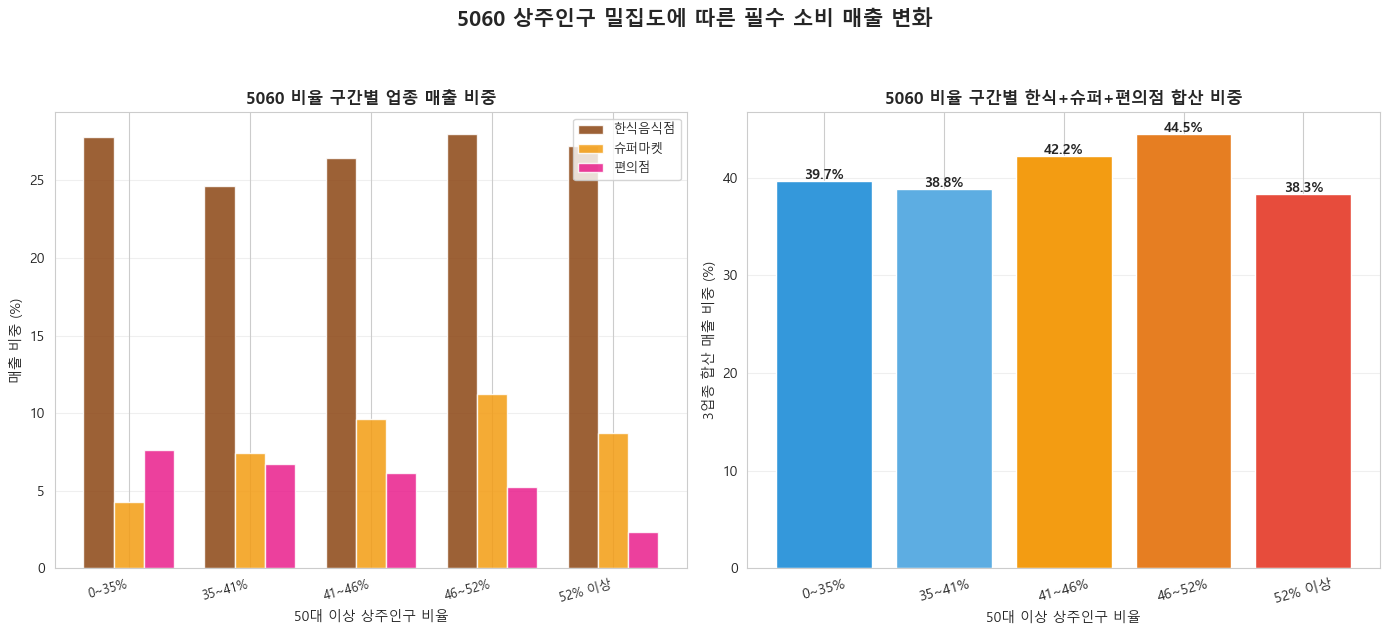

In [226]:
# %% 5060 상주 비율 5분위별 분석 및 시각화 (색상 동기화 버전)

# 1. 5060 상주 비율 5분위 구간 나누기 (실제 경곗값 bins 추출)
merged_df['5060_구간'], bins = pd.qcut(
    merged_df['5060_상주_비율'].dropna(), q=5, retbins=True, duplicates='drop'
)

# 2. 직관적인 구간 라벨 자동 생성
라벨 = [f'{bins[i]:.0f}~{bins[i+1]:.0f}%' for i in range(len(bins)-2)]
라벨.append(f'{bins[-2]:.0f}% 이상')

merged_df['5060_구간'] = pd.qcut(
    merged_df['5060_상주_비율'].dropna(), q=5, labels=라벨, duplicates='drop'
)
 
# 3. 구간별 평균 집계
구간별 = merged_df.groupby('5060_구간').agg(
    평균5060=('5060_상주_비율', 'mean'),
    한식=('한식_비중', 'mean'),
    슈퍼=('슈퍼_비중', 'mean'),
    편의점=('편의점_비중', 'mean'),
    합계=('TOP3_합산_비중', 'mean'),
    n=('상권_코드', 'count')
).reset_index()

# ==========================================
# 4. 시각화 시작
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# (1) 업종별 분리 (좌측 차트)
ax1 = axes[0]
x = np.arange(len(구간별))
w = 0.25

# 💡 2030과 완벽하게 동일한 색상 적용 (브라운, 오렌지, 핑크)
ax1.bar(x - w, 구간별['한식'], w, color='#8B4513', alpha=0.85, label='한식음식점')
ax1.bar(x, 구간별['슈퍼'], w, color='#F39C12', alpha=0.85, label='슈퍼마켓')
ax1.bar(x + w, 구간별['편의점'], w, color='#E91E8C', alpha=0.85, label='편의점')

ax1.set_xticks(x)
ax1.set_xticklabels(구간별['5060_구간'], fontsize=9, rotation=15, ha='right')
ax1.set_ylabel('매출 비중 (%)')
ax1.set_xlabel('50대 이상 상주인구 비율')
ax1.set_title('5060 비율 구간별 업종 매출 비중', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
 
# (2) 3업종 합산 (우측 차트)
ax2 = axes[1]
# 💡 2030과 완벽하게 동일한 그라데이션 색상 적용
colors = ['#3498DB', '#5DADE2', '#F39C12', '#E67E22', '#E74C3C']
bars = ax2.bar(구간별['5060_구간'], 구간별['합계'], color=colors, edgecolor='white')

ax2.set_ylabel('3업종 합산 매출 비중 (%)')
ax2.set_xlabel('50대 이상 상주인구 비율')
ax2.set_title('5060 비율 구간별 한식+슈퍼+편의점 합산 비중', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=15)
 
# 막대 위 수치 텍스트 표시
for bar, val in zip(bars, 구간별['합계']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
 
plt.suptitle('5060 상주인구 밀집도에 따른 필수 소비 매출 변화', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [227]:
# %% 필수 생활 3업종 간 상관관계 + 상권 유형 비교 (5060 타겟)

# 💡 [에러 해결!] df_상주 데이터에서 '상권_구분_코드_명'만 쏙 뽑아서 merged_df에 붙여줍니다.
if '상권_구분_코드_명' not in merged_df.columns:
    merged_df = merged_df.merge(
        df_상주[['기준_년분기_코드', '상권_코드', '상권_구분_코드_명']].drop_duplicates(),
        on=['기준_년분기_코드', '상권_코드'], 
        how='left'
    )

# 1. 3업종 간 상관관계 분석
corr_3 = merged_df[['한식_비중', '슈퍼_비중', '편의점_비중']].corr()
 
print('📊 필수 생활 3업종 간 상관관계')
print(corr_3.round(3))
 
# 2. 업종별 비중 상위 20% 상권 데이터 추출
한식_상위 = merged_df[merged_df['한식_비중'] > merged_df['한식_비중'].quantile(0.8)]
슈퍼_상위 = merged_df[merged_df['슈퍼_비중'] > merged_df['슈퍼_비중'].quantile(0.8)]
편의점_상위 = merged_df[merged_df['편의점_비중'] > merged_df['편의점_비중'].quantile(0.8)]
 
# 3. 상위 상권 프로필 비교 출력
print('\n📊 5060 타겟 업종별 상위 20% 상권 프로필 비교')
print(f'{"":>12} {"5060비율":>8} {"한식":>8} {"슈퍼":>8} {"편의점":>8} {"상권구성":>30}')
print('-' * 80)

for name, df in [('한식 상위', 한식_상위), ('슈퍼 상위', 슈퍼_상위), ('편의점 상위', 편의점_상위)]:
    # 상권 구분(골목, 발달, 전통시장 등) 비율 추출
    구성 = df['상권_구분_코드_명'].value_counts(normalize=True).head(3)
    구성str = ', '.join([f'{k} {v*100:.0f}%' for k, v in 구성.items()])
    
    # 간격에 맞추어 데이터 출력
    print(f'{name:>12} {df["5060_상주_비율"].mean():>7.1f}%'
          f' {df["한식_비중"].mean():>7.1f}%'
          f' {df["슈퍼_비중"].mean():>7.1f}%'
          f' {df["편의점_비중"].mean():>7.1f}%'
          f' {구성str:>30}')

📊 필수 생활 3업종 간 상관관계
        한식_비중  슈퍼_비중  편의점_비중
한식_비중    1.00  -0.18   -0.10
슈퍼_비중   -0.18   1.00   -0.03
편의점_비중  -0.10  -0.03    1.00

📊 5060 타겟 업종별 상위 20% 상권 프로필 비교
               5060비율       한식       슈퍼      편의점                           상권구성
--------------------------------------------------------------------------------
       한식 상위    44.2%    69.7%     3.1%     2.7%    골목상권 82%, 전통시장 14%, 발달상권 4%
       슈퍼 상위    45.6%    19.7%    33.5%     5.9%    골목상권 80%, 전통시장 17%, 발달상권 4%
      편의점 상위    40.2%    23.5%     8.2%    22.8%    골목상권 86%, 발달상권 12%, 전통시장 2%


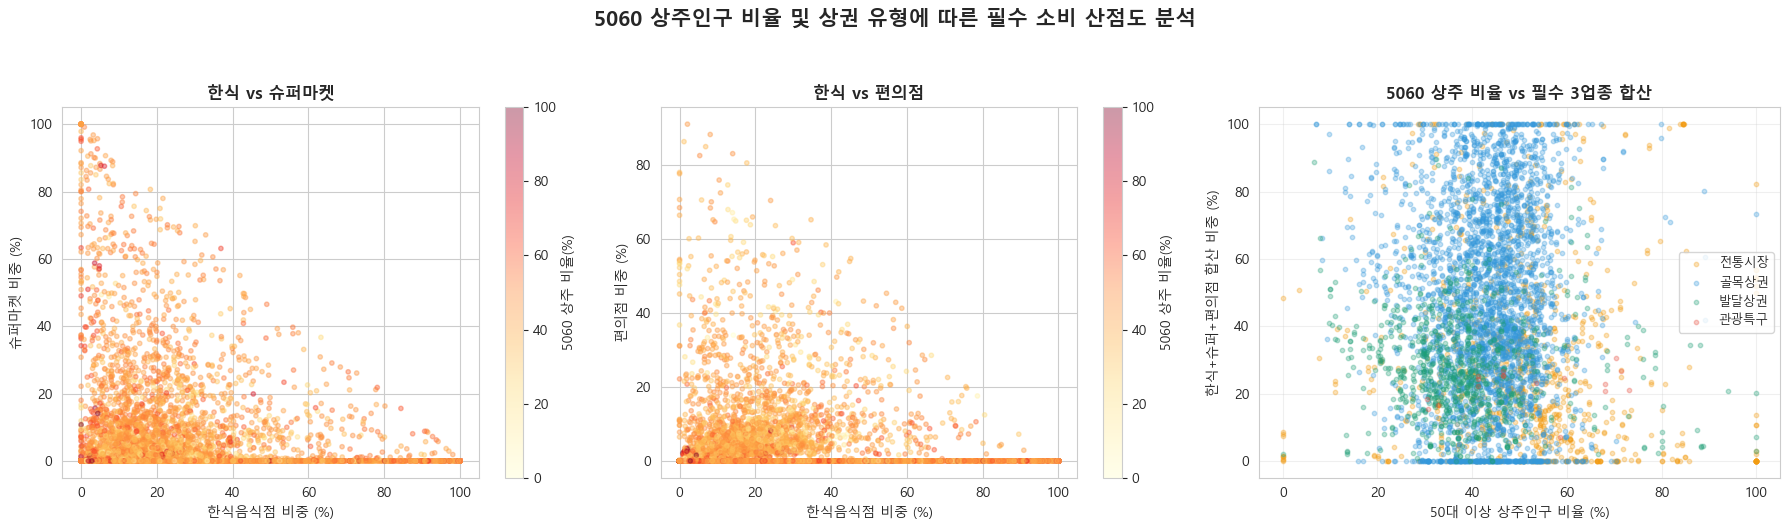

In [228]:
# %% 5060 산점도: 한식 vs 슈퍼/편의점 (5060 상주 비율 색상)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# 너무 많은 점이 겹치는 것을 방지하기 위한 샘플링 (랜덤 시드 고정)
sample = merged_df.sample(n=min(5000, len(merged_df)), random_state=42)
 
# (1) 한식 vs 슈퍼마켓 (색상: 5060 상주 비율)
ax1 = axes[0]
sc = ax1.scatter(sample['한식_비중'], sample['슈퍼_비중'],
                 c=sample['5060_상주_비율'], cmap='YlOrRd', alpha=0.4, s=10)
ax1.set_xlabel('한식음식점 비중 (%)')
ax1.set_ylabel('슈퍼마켓 비중 (%)')
ax1.set_title('한식 vs 슈퍼마켓', fontweight='bold')
plt.colorbar(sc, ax=ax1, label='5060 상주 비율(%)')
 
# (2) 한식 vs 편의점 (색상: 5060 상주 비율)
ax2 = axes[1]
sc2 = ax2.scatter(sample['한식_비중'], sample['편의점_비중'],
                  c=sample['5060_상주_비율'], cmap='YlOrRd', alpha=0.4, s=10)
ax2.set_xlabel('한식음식점 비중 (%)')
ax2.set_ylabel('편의점 비중 (%)')
ax2.set_title('한식 vs 편의점', fontweight='bold')
plt.colorbar(sc2, ax=ax2, label='5060 상주 비율(%)')
 
# (3) 5060 상주 비율 vs 3업종 합산 (상권 유형별 색상)
ax3 = axes[2]
색_map = {'골목상권':'#3498DB','발달상권':'#1D9E75','관광특구':'#E74C3C','전통시장':'#F39C12'}

# 상권 구분이 존재하는 데이터만 추출하여 반복문 실행
상권_list = sample['상권_구분_코드_명'].dropna().unique()

for 구분 in 상권_list:
    sub = sample[sample['상권_구분_코드_명'] == 구분]
    # get 메서드를 써서 딕셔너리에 없는 값이 나와도 에러가 나지 않도록 방어 코드 작성
    ax3.scatter(sub['5060_상주_비율'], sub['TOP3_합산_비중'],
                alpha=0.3, s=10, color=색_map.get(구분, 'gray'), label=구분)
    
ax3.set_xlabel('50대 이상 상주인구 비율 (%)')
ax3.set_ylabel('한식+슈퍼+편의점 합산 비중 (%)')
ax3.set_title('5060 상주 비율 vs 필수 3업종 합산', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)
 
plt.suptitle('5060 상주인구 비율 및 상권 유형에 따른 필수 소비 산점도 분석', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

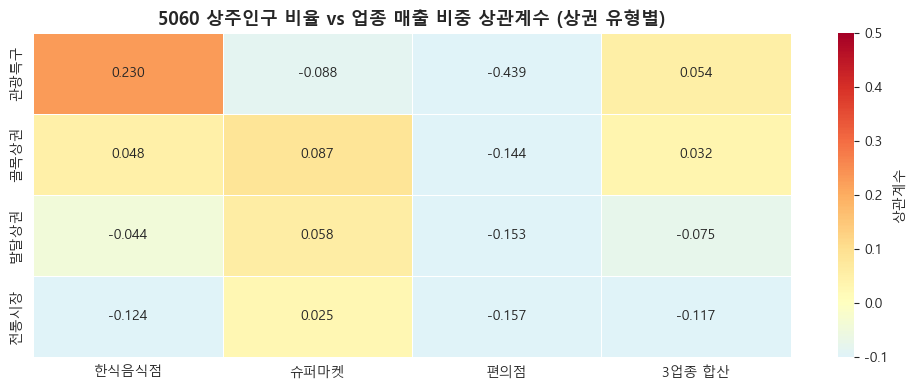

In [229]:
# %% 히트맵: 5060 상주 비율 vs 필수 3업종 매출 비중
corr_data = []

# 상권 구분이 존재하는 고유값 리스트 추출
상권_list = merged_df['상권_구분_코드_명'].dropna().unique()

for 구분 in 상권_list:
    sub = merged_df[merged_df['상권_구분_코드_명'] == 구분]
    row = []
    
    # 한식, 슈퍼마켓, 편의점, 그리고 TOP3 합산 비중까지 4개 컬럼 순회
    for col in ['한식_비중', '슈퍼_비중', '편의점_비중', 'TOP3_합산_비중']:
        # 데이터가 2개 이상 있어야 상관계수 계산 가능 (에러 방지)
        if len(sub) > 1:
            c = sub[['5060_상주_비율', col]].corr().iloc[0, 1]
        else:
            c = np.nan
        row.append(c)
        
    corr_data.append(row)
 
# 리스트를 데이터프레임으로 변환 (인덱스와 컬럼명 지정)
corr_df = pd.DataFrame(corr_data, index=상권_list, columns=['한식음식점', '슈퍼마켓', '편의점', '3업종 합산'])
 
# 시각화 그리기
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='RdYlBu_r',
            center=0, vmin=-0.1, vmax=0.5, ax=ax,
            linewidths=0.5, cbar_kws={'label': '상관계수'})

ax.set_title('5060 상주인구 비율 vs 업종 매출 비중 상관계수 (상권 유형별)', fontsize=13, fontweight='bold')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [230]:
# %% 5060 성별 분석 및 데이터 준비
# 1. 성별/업종별 매출 집계 (5060 타겟 업종: 한식, 슈퍼, 편의점)
타겟3_5060 = ['한식음식점', '슈퍼마켓', '편의점']
타겟_sales_5060 = sales[sales['서비스_업종_코드_명'].isin(타겟3_5060)]

성별_타겟_5060 = 타겟_sales_5060.groupby(
    ['기준_년분기_코드', '상권_코드', '서비스_업종_코드_명']
).agg(남성=('남성_매출_금액', 'sum'), 여성=('여성_매출_금액', 'sum'), 총=('당월_매출_금액', 'sum')).reset_index()

# 2. 5060 상주인구 비율 데이터와 병합 (df_상주 활용)
# (앞서 만든 5060_상주_비율 컬럼이 df_상주에 포함되어 있어야 합니다)
성별_타겟_5060 = 성별_타겟_5060.merge(
    df_상주[['기준_년분기_코드', '상권_코드', '5060_상주_비율']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)

# 3. 성별 매출 비율 계산
성별_타겟_5060['여성비율'] = 성별_타겟_5060['여성'] / 성별_타겟_5060['총'].replace(0, np.nan) * 100
성별_타겟_5060['남성비율'] = 성별_타겟_5060['남성'] / 성별_타겟_5060['총'].replace(0, np.nan) * 100

# 4. 5060 상주 비율 기준 3구간 분할
성별_타겟_5060['5060_상주_구간'] = pd.qcut(
    성별_타겟_5060['5060_상주_비율'].dropna(), q=3,
    labels=['5060 낮음', '5060 중간', '5060 높음'], duplicates='drop'
)

# 5. 결과 출력 (2030 형식과 동일하게 유지)
print('📊 5060 상주 구간 × 업종 × 성별 매출 비율')
print(f'{"업종":<15} {"5060 구간":<12} {"여성매출비율":>12} {"남성매출비율":>12}') 
print('-' * 60) 

for 업종 in 타겟3_5060:
    for 구간 in ['5060 낮음', '5060 중간', '5060 높음']:
        # 해당 업종과 구간에 맞는 데이터 필터링
        sub = 성별_타겟_5060[(성별_타겟_5060['서비스_업종_코드_명'] == 업종) & (성별_타겟_5060['5060_상주_구간'] == 구간)]
        
        # 평균 비중 산출
        여성_평균 = sub["여성비율"].mean()
        남성_평균 = sub["남성비율"].mean()
        
        # 여성과 남성 비율을 나란히 출력
        print(f'{업종:<15} {구간:<12} {여성_평균:>11.1f}% {남성_평균:>11.1f}%')

📊 5060 상주 구간 × 업종 × 성별 매출 비율
업종              5060 구간            여성매출비율       남성매출비율
------------------------------------------------------------
한식음식점           5060 낮음             30.0%        51.0%
한식음식점           5060 중간             32.1%        53.7%
한식음식점           5060 높음             31.9%        55.7%
슈퍼마켓            5060 낮음             39.7%        54.7%
슈퍼마켓            5060 중간             40.7%        55.3%
슈퍼마켓            5060 높음             40.2%        55.7%
편의점             5060 낮음             36.4%        61.5%
편의점             5060 중간             34.5%        64.0%
편의점             5060 높음             33.6%        64.9%


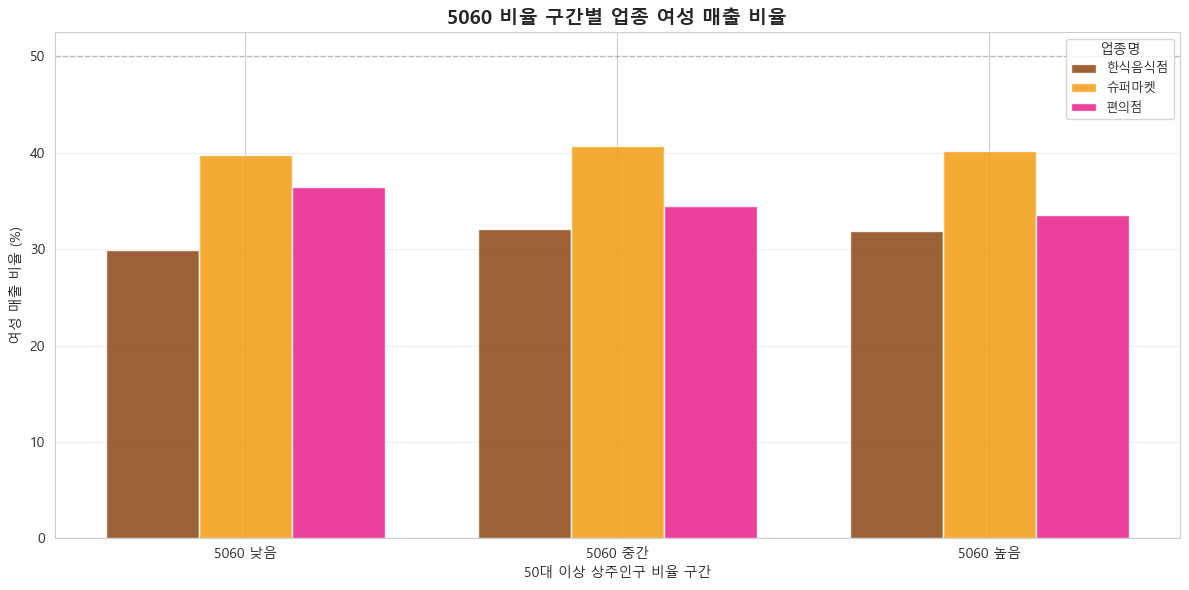

In [231]:
# %% 5060 상주 비율 구간별 업종 여성 매출 비율 시각화 (에러 수정 버전)

# 💡 [해결!] merged_df 대신 서비스_업종_코드_명 컬럼이 살아있는 성별_타겟_5060을 사용합니다.
# 또한 구간 명칭도 성별_타겟_5060에서 만든 '5060_상주_구간'으로 맞춰줍니다.
성별결과_5060 = 성별_타겟_5060.groupby(['서비스_업종_코드_명', '5060_상주_구간'])['여성비율'].mean().reset_index()
 
# 2. 그래프 설정
fig, ax = plt.subplots(figsize=(12, 6))

# 2030과 동일한 색상 매핑
업종색 = {'한식음식점': '#8B4513', '슈퍼마켓': '#F39C12', '편의점': '#E91E8C'}
타겟3_5060 = ['한식음식점', '슈퍼마켓', '편의점']

# 3개 구간(낮음, 중간, 높음)에 맞춰 x축 범위 설정
x = np.arange(3)
w = 0.25 
 
# 3. 업종별 막대 그래프 생성
for i, 업종 in enumerate(타겟3_5060):
    sub = 성별결과_5060[성별결과_5060['서비스_업종_코드_명'] == 업종]
    # x 위치를 조정하여 막대를 나란히 배치
    ax.bar(x + i*w - w, sub['여성비율'].values, w, color=업종색[업종], alpha=0.85, label=업종)
 
# 4. 차트 디테일 설정
ax.set_xticks(x)
ax.set_xticklabels(['5060 낮음', '5060 중간', '5060 높음']) # 구간명 고정

ax.set_ylabel('여성 매출 비율 (%)')
ax.set_xlabel('50대 이상 상주인구 비율 구간')
ax.set_title('5060 비율 구간별 업종 여성 매출 비율', fontweight='bold', fontsize=14)

ax.legend(title='업종명', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 50% 기준선
ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

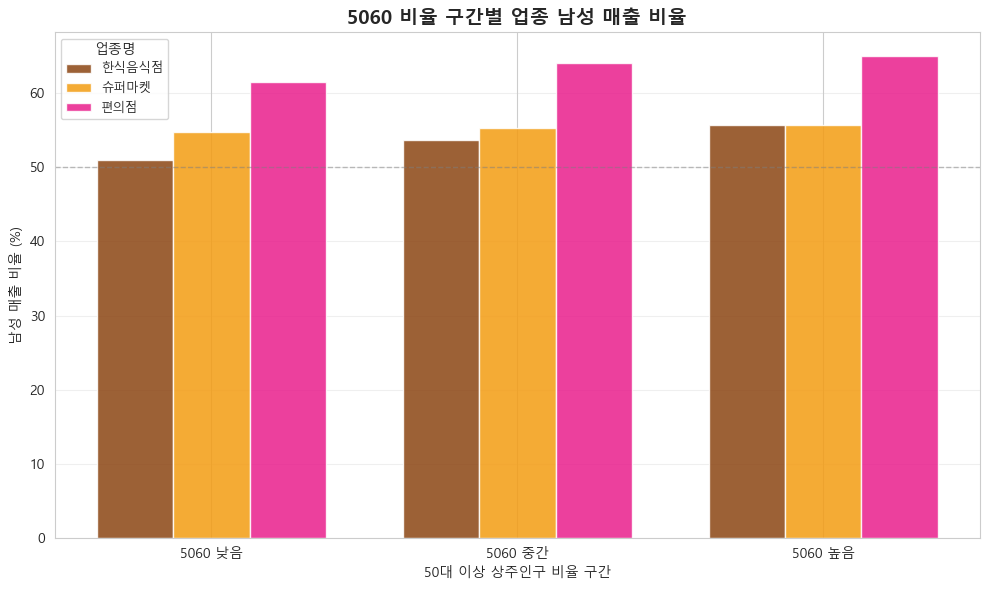

In [232]:
# %% 5060 상주 비율 구간별 업종 [남성] 매출 비율 시각화

# 1. 5060 남성 매출 데이터 집계 (Long Format 데이터인 성별_타겟_5060 활용)
성별결과_5060_남성 = 성별_타겟_5060.groupby(['서비스_업종_코드_명', '5060_상주_구간'])['남성비율'].mean().reset_index()
 
# 2. 그래프 설정
fig, ax = plt.subplots(figsize=(10, 6))

# 💡 2030과 완벽하게 동일한 색상 매핑 (한식: 브라운, 슈퍼: 오렌지, 편의점: 핑크)
업종색 = {'한식음식점': '#8B4513', '슈퍼마켓': '#F39C12', '편의점': '#E91E8C'}
타겟3_5060 = ['한식음식점', '슈퍼마켓', '편의점']

# 3개 구간(낮음, 중간, 높음)에 맞춰 x축 범위 설정
x = np.arange(3)
w = 0.25 # 막대 너비
 
# 3. 업종별 막대 그래프 생성 (남성비율 기준)
for i, 업종 in enumerate(타겟3_5060):
    sub = 성별결과_5060_남성[성별결과_5060_남성['서비스_업종_코드_명'] == 업종]
    # x 위치를 조정하여 막대를 나란히 배치
    ax.bar(x + i*w - w, sub['남성비율'].values, w, color=업종색[업종], alpha=0.85, label=업종)
 
# 4. 차트 디테일 설정
ax.set_xticks(x)
ax.set_xticklabels(['5060 낮음', '5060 중간', '5060 높음'])

ax.set_ylabel('남성 매출 비율 (%)')
ax.set_xlabel('50대 이상 상주인구 비율 구간')
ax.set_title('5060 비율 구간별 업종 남성 매출 비율', fontweight='bold', fontsize=14)

ax.legend(title='업종명', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 50% 기준선 (이 선을 넘으면 남성 소비가 주도적임을 의미)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

In [233]:
# %% 5060 시간대 분석
# 1. 5060 타겟 업종 데이터 필터링 및 시간대별 매출 집계
타겟3_5060 = ['한식음식점', '슈퍼마켓', '편의점']
시간_매출_cols = [c for c in sales.columns if '시간대' in c and '매출_금액' in c] # 시간대 컬럼 자동 추출

시간_타겟_5060 = sales[sales['서비스_업종_코드_명'].isin(타겟3_5060)].groupby(
    ['기준_년분기_코드', '상권_코드', '서비스_업종_코드_명']
)[시간_매출_cols + ['당월_매출_금액']].sum().reset_index()

# 2. 5060 상주인구 비율 데이터와 병합 (df_상주 활용)
시간_타겟_5060 = 시간_타겟_5060.merge(
    df_상주[['기준_년분기_코드', '상권_코드', '5060_상주_비율']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)

# 3. 5060 상주 비율 기준 3구간 분할
시간_타겟_5060['5060_상주_구간'] = pd.qcut(
    시간_타겟_5060['5060_상주_비율'].dropna(), q=3,
    labels=['5060 낮음', '5060 중간', '5060 높음'], duplicates='drop'
)

# 시간대 라벨 설정 (출력용)
시간라벨 = ['00-06', '06-11', '11-14', '14-17', '17-21', '21-24']

# 4. 결과 출력
print('\n📊 5060 상주 구간 × 업종 × 시간대 매출 비중')
for 업종 in 타겟3_5060:
    print(f'\n▸ {업종}')
    print(f'  {"구간":<12}', end='')
    for l in 시간라벨:
        print(f' {l:>7}', end='')
    print()
    
    for 구간 in ['5060 낮음', '5060 중간', '5060 높음']:
        sub = 시간_타겟_5060[(시간_타겟_5060['서비스_업종_코드_명'] == 업종) & (시간_타겟_5060['5060_상주_구간'] == 구간)]
        print(f'  {구간:<12}', end='')
        
        for col in 시간_매출_cols:
            # 0으로 나누기 방지 및 평균 비중 계산
            비중 = (sub[col] / sub['당월_매출_금액'].replace(0, np.nan) * 100).mean()
            print(f' {비중:>6.1f}%', end='')
        print()


📊 5060 상주 구간 × 업종 × 시간대 매출 비중

▸ 한식음식점
  구간             00-06   06-11   11-14   14-17   17-21   21-24
  5060 낮음         2.8%    2.1%   30.4%    9.7%   40.3%   14.7%
  5060 중간         2.5%    2.2%   28.5%   11.1%   41.8%   14.0%
  5060 높음         2.1%    2.5%   28.1%   12.7%   41.9%   12.8%

▸ 슈퍼마켓
  구간             00-06   06-11   11-14   14-17   17-21   21-24
  5060 낮음         3.9%   12.5%   17.5%   19.9%   32.3%   13.9%
  5060 중간         2.6%   11.7%   16.7%   20.7%   34.9%   13.4%
  5060 높음         2.7%   13.0%   18.0%   21.8%   32.9%   11.5%

▸ 편의점
  구간             00-06   06-11   11-14   14-17   17-21   21-24
  5060 낮음        10.0%   14.7%   13.9%   14.2%   27.7%   19.5%
  5060 중간        10.4%   15.1%   13.0%   13.8%   27.8%   19.7%
  5060 높음        10.3%   16.6%   13.4%   14.3%   27.4%   18.0%


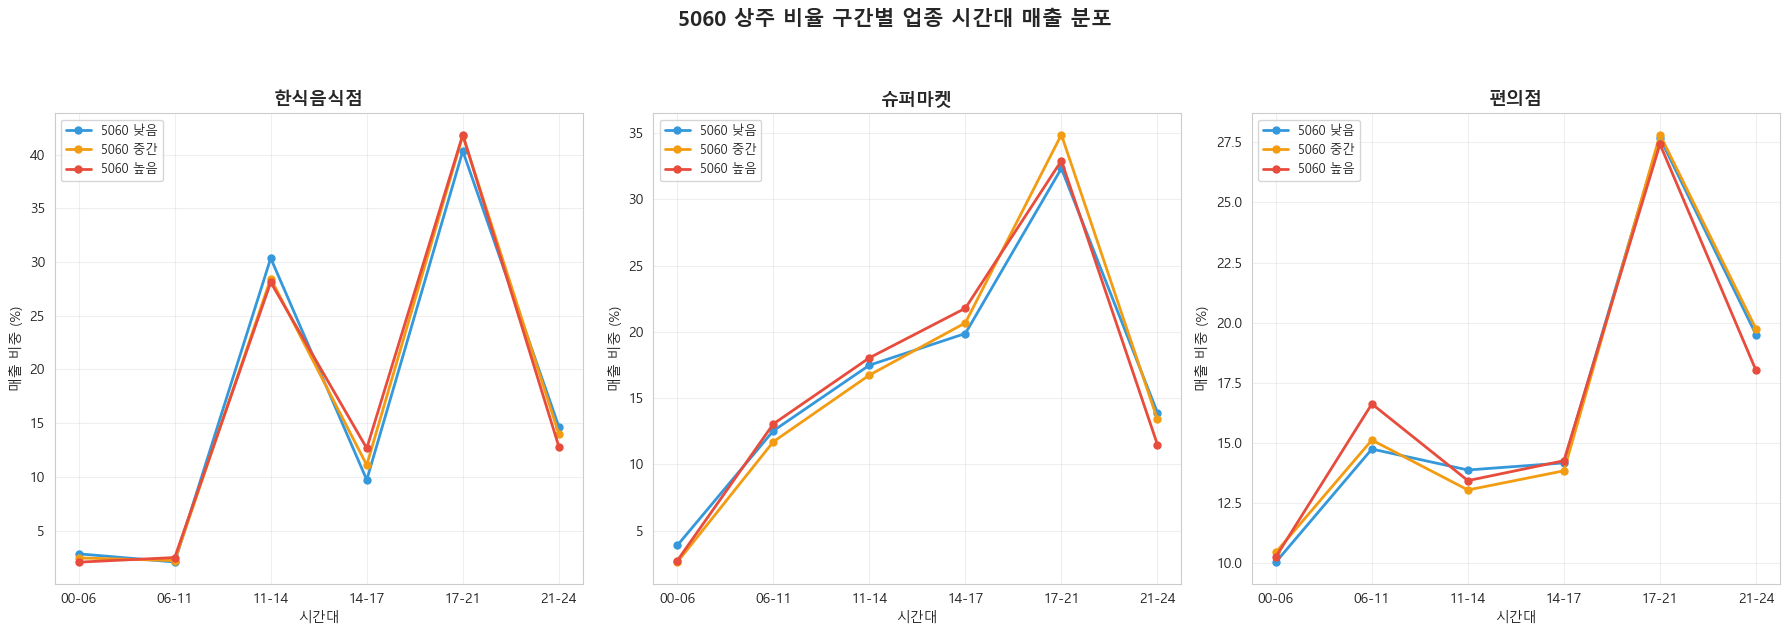

In [234]:
# %% 5060 상주 비율 구간별 업종 시간대 매출 분포 시각화

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 분석 대상 업종 정의
타겟3_5060 = ['한식음식점', '슈퍼마켓', '편의점']

for idx, 업종 in enumerate(타겟3_5060):
    ax = axes[idx]
    # 2030 코드와 동일한 색상 팔레트 유지
    구간색 = {'5060 낮음': '#3498DB', '5060 중간': '#F39C12', '5060 높음': '#E74C3C'}

    for 구간 in ['5060 낮음', '5060 중간', '5060 높음']:
        # 해당 업종과 구간 필터링
        sub = 시간_타겟_5060[(시간_타겟_5060['서비스_업종_코드_명'] == 업종) & 
                           (시간_타겟_5060['5060_상주_구간'] == 구간)]
        
        # 시간대별 매출 비중 평균 계산
        비중 = [(sub[col] / sub['당월_매출_금액'].replace(0, np.nan) * 100).mean() for col in 시간_매출_cols]
        
        # 꺾은선 그래프 그리기
        ax.plot(시간라벨, 비중, marker='o', markersize=5, linewidth=2,
                color=구간색[구간], label=구간)

    # 개별 차트 디테일
    ax.set_title(업종, fontweight='bold', fontsize=13)
    ax.set_xlabel('시간대')
    ax.set_ylabel('매출 비중 (%)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# 전체 타이틀 및 레이아웃 조정
fig.suptitle('5060 상주 비율 구간별 업종 시간대 매출 분포', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [235]:
# %% 5060 요일 분석
# 1. 5060 타겟 업종 데이터 필터링 및 요일별 매출 집계
타겟3_5060 = ['한식음식점', '슈퍼마켓', '편의점']
요일_매출_cols = [c for c in sales.columns if '요일' in c and '매출_금액' in c] # 요일 컬럼 자동 추출

요일_타겟_5060 = sales[sales['서비스_업종_코드_명'].isin(타겟3_5060)].groupby(
    ['기준_년분기_코드', '상권_코드', '서비스_업종_코드_명']
)[요일_매출_cols + ['당월_매출_금액']].sum().reset_index()

# 2. 5060 상주인구 비율 데이터와 병합 (df_상주 활용)
요일_타겟_5060 = 요일_타겟_5060.merge(
    df_상주[['기준_년분기_코드', '상권_코드', '5060_상주_비율']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)

# 3. 5060 상주 비율 기준 3구간 분할
요일_타겟_5060['5060_상주_구간'] = pd.qcut(
    요일_타겟_5060['5060_상주_비율'].dropna(), q=3,
    labels=['5060 낮음', '5060 중간', '5060 높음'], duplicates='drop'
)

# 요일 라벨 설정 (출력용)
요일라벨 = ['월', '화', '수', '목', '금', '토', '일']

# 4. 결과 출력
print('\n📊 5060 상주 구간 × 업종 × 요일 매출 비중')
for 업종 in 타겟3_5060:
    print(f'\n▸ {업종}')
    print(f'  {"구간":<12}', end='')
    for l in 요일라벨:
        print(f' {l:>6}', end='')
    print()
    
    for 구간 in ['5060 낮음', '5060 중간', '5060 높음']:
        sub = 요일_타겟_5060[(요일_타겟_5060['서비스_업종_코드_명'] == 업종) & (요일_타겟_5060['5060_상주_구간'] == 구간)]
        print(f'  {구간:<12}', end='')
        
        for col in 요일_매출_cols:
            # 0으로 나누기 방지 및 평균 비중 계산
            비중 = (sub[col] / sub['당월_매출_금액'].replace(0, np.nan) * 100).mean()
            print(f' {비중:>5.1f}%', end='')
        print()


📊 5060 상주 구간 × 업종 × 요일 매출 비중

▸ 한식음식점
  구간                월      화      수      목      금      토      일
  5060 낮음       13.7%  14.7%  15.1%  15.4%  16.6%  14.3%  10.2%
  5060 중간       13.0%  14.0%  14.4%  14.6%  16.2%  16.1%  11.8%
  5060 높음       12.8%  13.9%  14.2%  14.4%  16.1%  16.4%  12.2%

▸ 슈퍼마켓
  구간                월      화      수      목      금      토      일
  5060 낮음       14.6%  14.7%  14.7%  14.8%  15.7%  14.1%  11.5%
  5060 중간       14.2%  14.2%  14.3%  14.2%  15.5%  15.1%  12.6%
  5060 높음       14.4%  14.2%  14.4%  14.4%  15.4%  15.0%  12.2%

▸ 편의점
  구간                월      화      수      목      금      토      일
  5060 낮음       14.1%  14.3%  14.5%  14.7%  15.7%  14.2%  12.4%
  5060 중간       14.0%  14.1%  14.2%  14.4%  15.4%  14.7%  13.1%
  5060 높음       14.1%  14.2%  14.4%  14.4%  15.5%  14.6%  12.8%


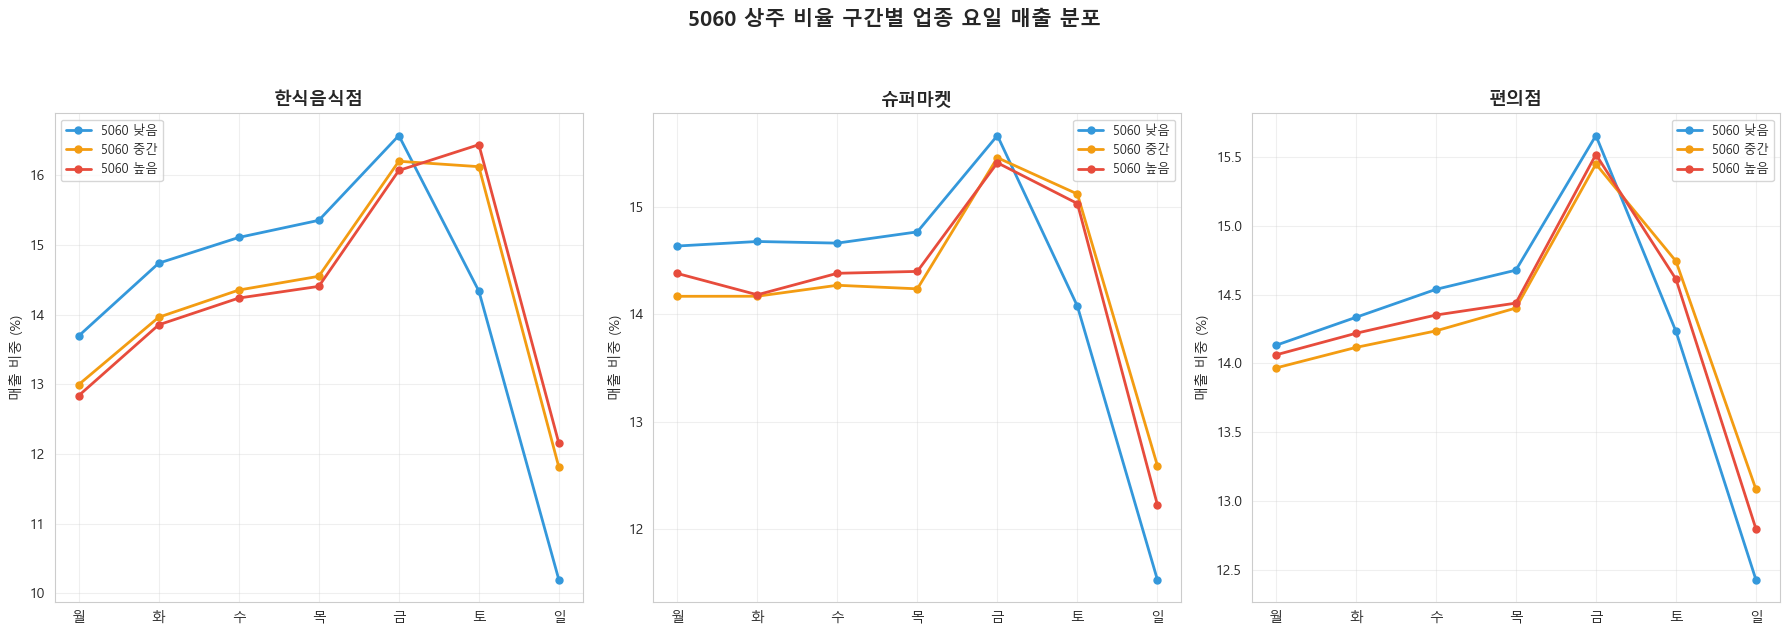

In [ ]:
# %% 5060 상주 비율 구간별 업종 요일 매출 분포 시각화

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 분석 대상 5060 타겟 업종
타겟3_5060 = ['한식음식점', '슈퍼마켓', '편의점']
 
for idx, 업종 in enumerate(타겟3_5060):
    ax = axes[idx]
    # 2030 코드와 동일한 색상 팔레트 유지
    구간색 = {'5060 낮음': '#3498DB', '5060 중간': '#F39C12', '5060 높음': '#E74C3C'}
 
    for 구간 in ['5060 낮음', '5060 중간', '5060 높음']:
        # 해당 업종과 구간 필터링
        sub = 요일_타겟_5060[(요일_타겟_5060['서비스_업종_코드_명'] == 업종) & 
                           (요일_타겟_5060['5060_상주_구간'] == 구간)]
        
        # 요일별 매출 비중 평균 계산 (요일_매출_cols 활용)
        비중 = [(sub[col] / sub['당월_매출_금액'].replace(0, np.nan) * 100).mean() for col in 요일_매출_cols]
        
        # 꺾은선 그래프 생성
        ax.plot(요일라벨, 비중, marker='o', markersize=5, linewidth=2,
                color=구간색[구간], label=구간)
 
    # 차트 개별 설정
    ax.set_title(업종, fontweight='bold', fontsize=13)
    ax.set_ylabel('매출 비중 (%)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
 
# 전체 제목 및 레이아웃 정리
fig.suptitle('5060 상주 비율 구간별 업종 요일 매출 분포', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()